# Silent Struggle Analysis — Student Mental Health Dataset

Notebook ini disusun untuk kebutuhan lomba data analyst dengan output akhir berupa **hasil analisis, insight, dan rancangan solusi** terhadap isu kesehatan mental mahasiswa.

Fokus utama analisis ini bukan diagnosis medis, melainkan membaca **support gap**: kondisi ketika mahasiswa sudah menunjukkan indikasi masalah kesehatan mental, tetapi belum tersambung ke bantuan profesional.

## Alur notebook

1. Memahami kualitas dan struktur data.
2. Membersihkan data dan membuat fitur turunan.
3. Menentukan KPI utama untuk analisis lomba.
4. Menganalisis pola indikasi mental health.
5. Mengukur *silent struggle* dan *support gap*.
6. Membuat segmentasi prioritas yang bisa ditindaklanjuti.
7. Menyusun insight utama dan rancangan solusi berbasis data.
8. Mengekspor tabel dan visualisasi untuk laporan/presentasi.

> **Catatan etik:** seluruh label pada notebook ini adalah label analitik berbasis survei, bukan diagnosis psikologis/medis.

## 0. Problem Statement dan Research Question

Banyak kampus sudah memiliki layanan konseling, tetapi pendekatannya sering masih pasif: mahasiswa perlu datang sendiri untuk meminta bantuan. Padahal, tidak semua mahasiswa yang mengalami tekanan mental merasa siap, tahu, atau berani untuk mencari bantuan profesional.

Karena itu, pertanyaan utama pada analisis ini adalah:

> **Bagaimana kampus dapat mengidentifikasi kelompok mahasiswa yang memiliki indikasi masalah kesehatan mental tetapi belum mencari bantuan, lalu merancang intervensi awal yang aman, etis, dan berbasis data?**

### Research question pendukung

1. Seberapa besar proporsi mahasiswa yang melaporkan depression, anxiety, atau panic attack?
2. Berapa banyak mahasiswa yang memiliki beberapa indikator sekaligus?
3. Seberapa besar gap antara mahasiswa yang berindikasi dan mahasiswa yang mencari bantuan profesional?
4. Kelompok mana yang perlu diprioritaskan berdasarkan pola data?
5. Solusi seperti apa yang paling masuk akal untuk kampus berdasarkan temuan tersebut?

## 1. Setup Library

Bagian ini memuat library utama dan pengaturan tampilan agar tabel serta grafik lebih rapi.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Markdown

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
pd.set_option('display.max_colwidth', None)

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.titleweight': 'bold',
    'font.size': 10,
})

## 2. Load Dataset

Path dibuat fleksibel agar notebook bisa dijalankan dari folder lokal, Google Colab, ataupun struktur folder `dataset/`.

In [2]:
possible_paths = [
    Path('./dataset/Student Mental health.csv'),
    Path('./Student Mental health.csv'),
    Path('/mnt/data/Student Mental health.csv')
]

csv_path = next((path for path in possible_paths if path.exists()), None)

if csv_path is None:
    raise FileNotFoundError(
        'Dataset tidak ditemukan. Pastikan file "Student Mental health.csv" berada di folder yang sama dengan notebook atau di folder dataset/.'
    )

raw_df = pd.read_csv(csv_path)
df = raw_df.copy()

print(f'Dataset berhasil dimuat dari: {csv_path}')
print(f'Ukuran dataset: {df.shape[0]} baris dan {df.shape[1]} kolom')
display(df.head())

Dataset berhasil dimuat dari: dataset\Student Mental health.csv
Ukuran dataset: 101 baris dan 11 kolom


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.00,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.00,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.00,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.00,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.00,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


## 3. Data Understanding Awal

Sebelum masuk ke insight, kita cek tipe data, missing value, duplikasi, dan nilai unik. Ini penting karena dataset survei biasanya memiliki format kategori yang kurang seragam.

In [3]:
buffer = StringIO()
df.info(buf=buffer)
print(buffer.getvalue())

quality_raw = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'missing_count': df.isna().sum().values,
    'missing_pct': (df.isna().mean().values * 100).round(2),
    'unique_count': df.nunique(dropna=True).values
})

display(quality_raw)
print(f'Jumlah duplikasi baris penuh: {df.duplicated().sum()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    object 
 1   Choose your gender                            101 non-null    object 
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    object 
 4   Your current year of Study                    101 non-null    object 
 5   What is your CGPA?                            101 non-null    object 
 6   Marital status                                101 non-null    object 
 7   Do you have Depression?                       101 non-null    object 
 8   Do you have Anxiety?                          101 non-null    object 
 9   Do you have Panic attack?                     101 non-null    obj

,column,dtype,missing_count,missing_pct,unique_count
0,Timestamp,object,0,0.00,92
1,Choose your gender,object,0,0.00,2
2,Age,float64,1,0.99,7
3,What is your course?,object,0,0.00,49
4,Your current year of Study,object,0,0.00,7
5,What is your CGPA?,object,0,0.00,6
6,Marital status,object,0,0.00,2
7,Do you have Depression?,object,0,0.00,2
8,Do you have Anxiety?,object,0,0.00,2
9,Do you have Panic attack?,object,0,0.00,2


Jumlah duplikasi baris penuh: 0


In [4]:
# Ringkasan nilai unik agar proses cleaning lebih mudah diaudit.
unique_summary = []
for col in df.columns:
    values = df[col].dropna().astype(str).unique().tolist()
    unique_summary.append({
        'column': col,
        'unique_count': len(values),
        'sample_unique_values': ', '.join(values[:12]) + (' ...' if len(values) > 12 else '')
    })

unique_summary = pd.DataFrame(unique_summary)
display(unique_summary)

,column,unique_count,sample_unique_values
0,Timestamp,92,"8/7/2020 12:02, 8/7/2020 12:04, 8/7/2020 12:05..."
1,Choose your gender,2,"Female, Male"
2,Age,7,"18.0, 21.0, 19.0, 22.0, 23.0, 20.0, 24.0"
3,What is your course?,49,"Engineering, Islamic education, BIT, Laws, Mat..."
4,Your current year of Study,7,"year 1, year 2, Year 1, year 3, year 4, Year 2..."
5,What is your CGPA?,6,"3.00 - 3.49, 3.50 - 4.00, 3.50 - 4.00 , 2.50 -..."
6,Marital status,2,"No, Yes"
7,Do you have Depression?,2,"Yes, No"
8,Do you have Anxiety?,2,"No, Yes"
9,Do you have Panic attack?,2,"Yes, No"


## 4. Data Cleaning dan Standardisasi

Cleaning yang dilakukan:

- Menyederhanakan nama kolom.
- Menghapus spasi berlebih pada data teks.
- Memperbaiki parsing timestamp dengan format tanggal campuran.
- Menstandarkan tahun studi dan rentang CGPA.
- Menyatukan beberapa variasi penulisan jurusan/course.
- Mengubah jawaban Yes/No menjadi 1/0 agar mudah dihitung.

In [5]:
rename_map = {
    'Timestamp': 'timestamp',
    'Choose your gender': 'gender',
    'Age': 'age',
    'What is your course?': 'course',
    'Your current year of Study': 'year_study',
    'What is your CGPA?': 'cgpa',
    'Marital status': 'marital_status',
    'Do you have Depression?': 'depression',
    'Do you have Anxiety?': 'anxiety',
    'Do you have Panic attack?': 'panic_attack',
    'Did you seek any specialist for a treatment?': 'seek_specialist'
}

df_clean = df.rename(columns=rename_map).copy()

# Strip spasi pada semua kolom object.
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Parsing timestamp.
# Dataset memakai format seperti 8/7/2020 dan 13/07/2020, sehingga dayfirst=True lebih aman untuk konteks dd/mm/yyyy.
df_clean['timestamp'] = pd.to_datetime(
    df_clean['timestamp'],
    errors='coerce',
    dayfirst=True,
    format='mixed'
)

# Standarisasi gender.
df_clean['gender'] = df_clean['gender'].str.title()

# Standarisasi tahun studi, contoh: year 1, Year 1 -> Year 1.
df_clean['year_study'] = (
    df_clean['year_study']
    .str.lower()
    .str.extract(r'(\d+)')[0]
    .apply(lambda x: f'Year {x}' if pd.notna(x) else np.nan)
)

# Standarisasi CGPA.
df_clean['cgpa'] = df_clean['cgpa'].str.replace(r'\s+', ' ', regex=True).str.strip()

# Standarisasi course/jurusan.
def normalize_course(value):
    if pd.isna(value):
        return np.nan
    text = str(value).lower().strip()
    text = ' '.join(text.split())
    mapping = {
        'laws': 'law',
        'law': 'law',
        'islamic education': 'islamic education',
        'pendidikan islam': 'islamic education',
        'mathemathics': 'mathematics',
        'maths': 'mathematics',
        'mathematics': 'mathematics',
        'bcs': 'computer science',
        'bit': 'information technology',
        'engin': 'engineering',
        'engineering': 'engineering',
        'psychology': 'psychology',
        'human resources': 'human resources',
        'koe': 'koe',
        'kenms': 'kenms',
        'irkhs': 'irkhs',
        'benl': 'benl',
        'enm': 'enm',
        'usuluddin': 'usuluddin',
        'taasl': 'taasl',
        'ala': 'ala',
        'mhsc': 'mhsc',
        'biomedical science': 'biomedical science',
        'communication': 'communication',
        'diploma nursing': 'diploma nursing',
        'fiqh fatwa': 'fiqh fatwa',
        'it': 'information technology',
    }
    return mapping.get(text, text)

df_clean['course_clean'] = df_clean['course'].apply(normalize_course).str.title()

# Ubah Yes/No menjadi 1/0.
binary_cols = ['marital_status', 'depression', 'anxiety', 'panic_attack', 'seek_specialist']
for col in binary_cols:
    df_clean[col] = df_clean[col].astype(str).str.title().map({'Yes': 1, 'No': 0})

# Pastikan age numerik.
df_clean['age'] = pd.to_numeric(df_clean['age'], errors='coerce')

# Urutan kategorikal agar visualisasi lebih rapi.
cgpa_order = ['0 - 1.99', '2.00 - 2.49', '2.50 - 2.99', '3.00 - 3.49', '3.50 - 4.00']
year_order = ['Year 1', 'Year 2', 'Year 3', 'Year 4']

df_clean['cgpa'] = pd.Categorical(df_clean['cgpa'], categories=cgpa_order, ordered=True)
df_clean['year_study'] = pd.Categorical(df_clean['year_study'], categories=year_order, ordered=True)

cleaning_summary = pd.DataFrame({
    'column': df_clean.columns,
    'dtype_after_cleaning': df_clean.dtypes.astype(str).values,
    'missing_count': df_clean.isna().sum().values,
    'missing_pct': (df_clean.isna().mean().values * 100).round(2),
    'unique_count': df_clean.nunique(dropna=True).values
})

display(cleaning_summary)
display(df_clean.head())

,column,dtype_after_cleaning,missing_count,missing_pct,unique_count
0,timestamp,datetime64[ns],0,0.00,92
1,gender,object,0,0.00,2
2,age,float64,1,0.99,7
3,course,object,0,0.00,48
4,year_study,category,0,0.00,4
5,cgpa,category,0,0.00,5
6,marital_status,int64,0,0.00,2
7,depression,int64,0,0.00,2
8,anxiety,int64,0,0.00,2
9,panic_attack,int64,0,0.00,2


,timestamp,gender,age,course,year_study,cgpa,marital_status,depression,anxiety,panic_attack,seek_specialist,course_clean
0,2020-07-08 12:02:00,Female,18.00,Engineering,Year 1,3.00 - 3.49,0,1,0,1,0,Engineering
1,2020-07-08 12:04:00,Male,21.00,Islamic education,Year 2,3.00 - 3.49,0,0,1,0,0,Islamic Education
2,2020-07-08 12:05:00,Male,19.00,BIT,Year 1,3.00 - 3.49,0,1,1,1,0,Information Technology
3,2020-07-08 12:06:00,Female,22.00,Laws,Year 3,3.00 - 3.49,1,1,0,0,0,Law
4,2020-07-08 12:13:00,Male,23.00,Mathemathics,Year 4,3.00 - 3.49,0,0,0,0,0,Mathematics


## 5. Feature Engineering

Agar analisis lebih actionable, kita membuat beberapa fitur turunan:

- `issue_count`: jumlah indikator mental health yang dijawab Yes.
- `has_any_issue`: minimal memiliki satu indikator.
- `multiple_issue`: memiliki dua atau lebih indikator.
- `support_status`: status keterhubungan dengan bantuan profesional.
- `priority_segment`: segmentasi prioritas untuk rancangan solusi kampus.
- `age_group`: kelompok umur sederhana.

Bagian paling penting adalah `priority_segment`, karena hasil lomba tidak hanya membutuhkan insight, tetapi juga rancangan aksi.

In [6]:
mental_issue_cols = ['depression', 'anxiety', 'panic_attack']

df_clean['issue_count'] = df_clean[mental_issue_cols].sum(axis=1)
df_clean['has_any_issue'] = (df_clean['issue_count'] > 0).astype(int)
df_clean['multiple_issue'] = (df_clean['issue_count'] >= 2).astype(int)
df_clean['all_three_issues'] = (df_clean['issue_count'] == 3).astype(int)

df_clean['support_status'] = np.select(
    [
        df_clean['issue_count'].eq(0),
        df_clean['seek_specialist'].eq(1)
    ],
    [
        'Stable / No Reported Indicator',
        'Reached Support'
    ],
    default='Silent Struggle'
)

df_clean['risk_group'] = pd.cut(
    df_clean['issue_count'],
    bins=[-1, 0, 1, 3],
    labels=['Low / No Indicator', 'Single Indicator', 'Multiple Indicators']
)

# Segmentasi prioritas berbasis action, bukan diagnosis.
df_clean['priority_segment'] = np.select(
    [
        df_clean['issue_count'].eq(0),
        df_clean['seek_specialist'].eq(1),
        df_clean['issue_count'].ge(2) & df_clean['seek_specialist'].eq(0),
        df_clean['issue_count'].eq(1) & df_clean['seek_specialist'].eq(0),
    ],
    [
        'Stable',
        'Reached Support',
        'High Priority',
        'Medium Priority',
    ],
    default='Need Review'
)

priority_order = ['High Priority', 'Medium Priority', 'Reached Support', 'Stable']
df_clean['priority_segment'] = pd.Categorical(df_clean['priority_segment'], categories=priority_order, ordered=True)

# Kelompok umur sederhana.
df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[0, 18, 20, 22, 100],
    labels=['<=18', '19-20', '21-22', '23+']
)

selected_cols = [
    'gender', 'age', 'age_group', 'course_clean', 'year_study', 'cgpa',
    'depression', 'anxiety', 'panic_attack', 'seek_specialist',
    'issue_count', 'risk_group', 'support_status', 'priority_segment'
]

display(df_clean[selected_cols].head(10))

,gender,age,age_group,course_clean,year_study,cgpa,depression,anxiety,panic_attack,seek_specialist,issue_count,risk_group,support_status,priority_segment
0,Female,18.00,<=18,Engineering,Year 1,3.00 - 3.49,1,0,1,0,2,Multiple Indicators,Silent Struggle,High Priority
1,Male,21.00,21-22,Islamic Education,Year 2,3.00 - 3.49,0,1,0,0,1,Single Indicator,Silent Struggle,Medium Priority
2,Male,19.00,19-20,Information Technology,Year 1,3.00 - 3.49,1,1,1,0,3,Multiple Indicators,Silent Struggle,High Priority
3,Female,22.00,21-22,Law,Year 3,3.00 - 3.49,1,0,0,0,1,Single Indicator,Silent Struggle,Medium Priority
4,Male,23.00,23+,Mathematics,Year 4,3.00 - 3.49,0,0,0,0,0,Low / No Indicator,Stable / No Reported Indicator,Stable
5,Male,19.00,19-20,Engineering,Year 2,3.50 - 4.00,0,0,1,0,1,Single Indicator,Silent Struggle,Medium Priority
6,Female,23.00,23+,Islamic Education,Year 2,3.50 - 4.00,1,0,1,0,2,Multiple Indicators,Silent Struggle,High Priority
7,Female,18.00,<=18,Computer Science,Year 1,3.50 - 4.00,0,1,0,0,1,Single Indicator,Silent Struggle,Medium Priority
8,Female,19.00,19-20,Human Resources,Year 2,2.50 - 2.99,0,0,0,0,0,Low / No Indicator,Stable / No Reported Indicator,Stable
9,Male,18.00,<=18,Irkhs,Year 1,3.50 - 4.00,0,1,1,0,2,Multiple Indicators,Silent Struggle,High Priority


## 6. KPI Utama Analisis

Agar analisis tidak hanya berupa visualisasi, kita perlu KPI yang jelas. KPI utama yang dipakai adalah **Silent Struggle Rate**.

```text
Silent Struggle Rate = mahasiswa berindikasi tetapi belum mencari bantuan / mahasiswa yang memiliki minimal satu indikasi
```

KPI ini lebih kuat dibanding hanya menghitung jumlah mahasiswa yang mengalami depression/anxiety/panic attack, karena langsung mengarah ke masalah yang bisa diselesaikan kampus: **kesenjangan akses dukungan**.

In [ ]:
n = len(df_clean)
with_issue = int(df_clean['has_any_issue'].sum())
without_issue = n - with_issue
silent_struggle = int((df_clean['support_status'] == 'Silent Struggle').sum())
reached_support = int((df_clean['support_status'] == 'Reached Support').sum())
multiple_issue = int(df_clean['multiple_issue'].sum())
all_three = int(df_clean['all_three_issues'].sum())

at_risk_rate = with_issue / n * 100
silent_struggle_rate_total = silent_struggle / n * 100
silent_struggle_rate_at_risk = silent_struggle / with_issue * 100 if with_issue else 0
support_reach_rate = reached_support / with_issue * 100 if with_issue else 0
multiple_indicator_rate = multiple_issue / n * 100
all_three_rate = all_three / n * 100

kpi_summary = pd.DataFrame({
    'kpi': [
        'Total Respondents',
        'At-Risk Rate',
        'Silent Struggle Rate',
        'Support Reach Rate',
        'Multiple Indicator Rate',
        'All Three Indicators Rate'
    ],
    'definition': [
        'Jumlah responden dalam dataset',
        'Minimal memiliki 1 indikator mental health',
        'Berindikasi tetapi belum mencari bantuan, dibanding seluruh responden berindikasi',
        'Berindikasi dan sudah mencari bantuan, dibanding seluruh responden berindikasi',
        'Memiliki 2 atau lebih indikator mental health',
        'Melaporkan depression, anxiety, dan panic attack sekaligus'
    ],
    'value': [
        n,
        f'{with_issue} responden ({at_risk_rate:.1f}%)',
        f'{silent_struggle} responden ({silent_struggle_rate_at_risk:.1f}% dari at-risk)',
        f'{reached_support} responden ({support_reach_rate:.1f}% dari at-risk)',
        f'{multiple_issue} responden ({multiple_indicator_rate:.1f}%)',
        f'{all_three} responden ({all_three_rate:.1f}%)'
    ]
})


display(kpi_summary)

display(Markdown(f"""
### Narasi KPI

Dari **{n}** responden, terdapat **{with_issue} mahasiswa ({at_risk_rate:.1f}%)** yang memiliki minimal satu indikator mental health. Namun, dari kelompok yang sudah berindikasi tersebut, **{silent_struggle} mahasiswa ({silent_struggle_rate_at_risk:.1f}%)** belum mencari bantuan profesional.

Artinya, isu utama dataset ini bukan hanya tingginya indikasi mental health, tetapi **rendahnya keterhubungan mahasiswa berisiko dengan layanan bantuan**.
"""))

,kpi,definition,value
0,Total Respondents,Jumlah responden dalam dataset,101
1,At-Risk Rate,Minimal memiliki 1 indikator mental health,64 responden (63.4%)
2,Silent Struggle Rate,"Berindikasi tetapi belum mencari bantuan, dibanding seluruh responden berindikasi",58 responden (90.6% dari at-risk)
3,Support Reach Rate,"Berindikasi dan sudah mencari bantuan, dibanding seluruh responden berindikasi",6 responden (9.4% dari at-risk)
4,Multiple Indicator Rate,Memiliki 2 atau lebih indikator mental health,28 responden (27.7%)
5,All Three Indicators Rate,"Melaporkan depression, anxiety, dan panic attack sekaligus",10 responden (9.9%)



### Narasi KPI

Dari **101** responden, terdapat **64 mahasiswa (63.4%)** yang memiliki minimal satu indikator mental health. Namun, dari kelompok yang sudah berindikasi tersebut, **58 mahasiswa (90.6%)** belum mencari bantuan profesional.

Artinya, isu utama dataset ini bukan hanya tingginya indikasi mental health, tetapi **rendahnya keterhubungan mahasiswa berisiko dengan layanan bantuan**.


## 7. Gambaran Umum Indikator Mental Health

Bagian ini melihat prevalensi depression, anxiety, dan panic attack secara terpisah. Tujuannya untuk memahami indikator mana yang paling banyak muncul dalam dataset.

,indicator,count_yes,percentage_yes
0,Depression,35,34.65
1,Anxiety,34,33.66
2,Panic Attack,33,32.67


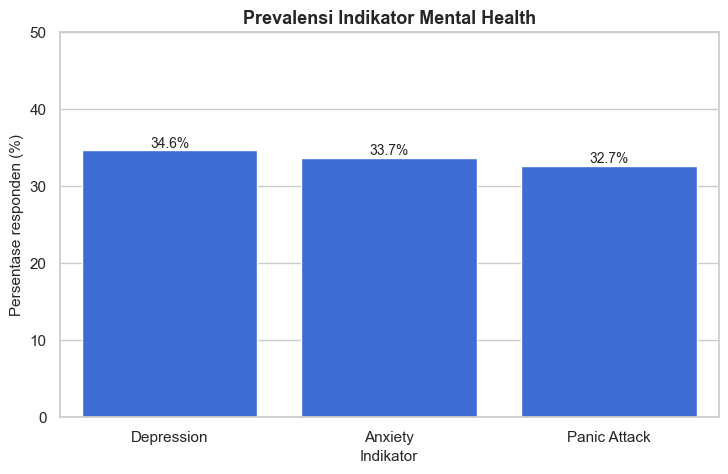

In [8]:
indicator_summary = pd.DataFrame({
    'indicator': ['Depression', 'Anxiety', 'Panic Attack'],
    'count_yes': [df_clean['depression'].sum(), df_clean['anxiety'].sum(), df_clean['panic_attack'].sum()],
})
indicator_summary['percentage_yes'] = (indicator_summary['count_yes'] / len(df_clean) * 100).round(2)
indicator_summary = indicator_summary.sort_values('percentage_yes', ascending=False)

display(indicator_summary)

plt.figure(figsize=(8.5, 5))
ax = sns.barplot(data=indicator_summary, x='indicator', y='percentage_yes', color='#2563EB')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.title('Prevalensi Indikator Mental Health')
plt.xlabel('Indikator')
plt.ylabel('Persentase responden (%)')
plt.ylim(0, max(50, indicator_summary['percentage_yes'].max() + 10))
plt.show()

In [9]:
top_indicator = indicator_summary.iloc[0]
lowest_indicator = indicator_summary.iloc[-1]

display(Markdown(f"""
### Interpretasi

Indikator dengan proporsi tertinggi adalah **{top_indicator['indicator']}** dengan **{int(top_indicator['count_yes'])} responden ({top_indicator['percentage_yes']:.1f}%)**. Sementara itu, indikator terendah adalah **{lowest_indicator['indicator']}** dengan **{int(lowest_indicator['count_yes'])} responden ({lowest_indicator['percentage_yes']:.1f}%)**.

Perbedaan antarindikator tidak boleh dibaca sebagai diagnosis, tetapi sebagai sinyal bahwa masalah mental health mahasiswa dapat muncul dalam beberapa bentuk sekaligus. Karena itu, pendekatan solusi sebaiknya tidak hanya fokus pada satu indikator.
"""))


### Interpretasi

Indikator dengan proporsi tertinggi adalah **Depression** dengan **35 responden (34.6%)**. Sementara itu, indikator terendah adalah **Panic Attack** dengan **33 responden (32.7%)**.

Perbedaan antarindikator tidak boleh dibaca sebagai diagnosis, tetapi sebagai sinyal bahwa masalah mental health mahasiswa dapat muncul dalam beberapa bentuk sekaligus. Karena itu, pendekatan solusi sebaiknya tidak hanya fokus pada satu indikator.


## 8. Kompleksitas Indikasi: 0, 1, 2, atau 3 Indikator

Mahasiswa dengan lebih dari satu indikator perlu mendapat perhatian lebih tinggi karena situasinya berpotensi lebih kompleks. Analisis ini membantu membedakan kelompok dengan satu indikator dan beberapa indikator sekaligus.

,issue_count,count,percentage
0,0,37,36.63
1,1,36,35.64
2,2,18,17.82
3,3,10,9.90


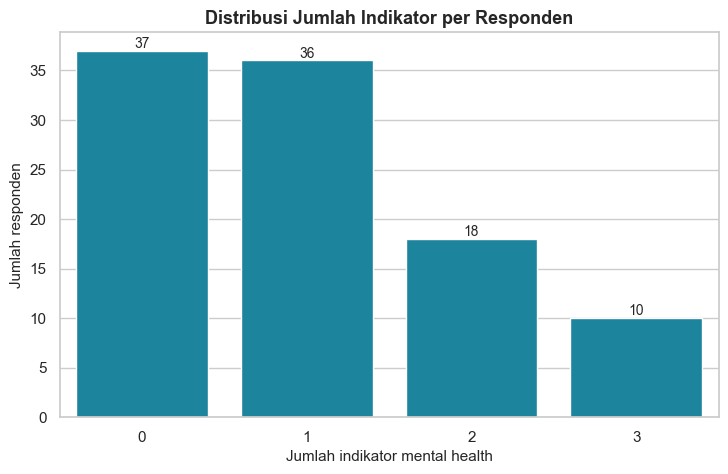

In [10]:
issue_count_summary = (
    df_clean['issue_count']
    .value_counts()
    .sort_index()
    .rename_axis('issue_count')
    .reset_index(name='count')
)
issue_count_summary['percentage'] = (issue_count_summary['count'] / len(df_clean) * 100).round(2)

display(issue_count_summary)

plt.figure(figsize=(8.5, 5))
ax = sns.barplot(data=issue_count_summary, x='issue_count', y='count', color='#0891B2')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Distribusi Jumlah Indikator per Responden')
plt.xlabel('Jumlah indikator mental health')
plt.ylabel('Jumlah responden')
plt.show()

In [11]:
issue_0 = int((df_clean['issue_count'] == 0).sum())
issue_1 = int((df_clean['issue_count'] == 1).sum())
issue_2plus = int((df_clean['issue_count'] >= 2).sum())

issue_2plus_pct = issue_2plus / n * 100

display(Markdown(f"""
### Interpretasi

Sebanyak **{issue_2plus} responden ({issue_2plus_pct:.1f}%)** memiliki dua atau lebih indikator sekaligus. Kelompok ini penting untuk rancangan solusi karena mereka tidak hanya membutuhkan awareness umum, tetapi berpotensi membutuhkan jalur pendampingan yang lebih terarah.
"""))


### Interpretasi

Sebanyak **28 responden (27.7%)** memiliki dua atau lebih indikator sekaligus. Kelompok ini penting untuk rancangan solusi karena mereka tidak hanya membutuhkan awareness umum, tetapi berpotensi membutuhkan jalur pendampingan yang lebih terarah.


## 9. Co-occurrence: Kombinasi Indikator yang Muncul Bersamaan

Analisis kombinasi membantu melihat apakah indikator muncul sendiri-sendiri atau bersamaan. Ini lebih informatif dibanding hanya menghitung tiap indikator secara terpisah.

,combination,count,percentage
0,No Indicator,37,36.63
1,Anxiety,13,12.87
2,Panic Attack,13,12.87
3,Depression + Anxiety + Panic Attack,10,9.90
4,Depression,10,9.90
5,Depression + Anxiety,8,7.92
6,Depression + Panic Attack,7,6.93
7,Anxiety + Panic Attack,3,2.97


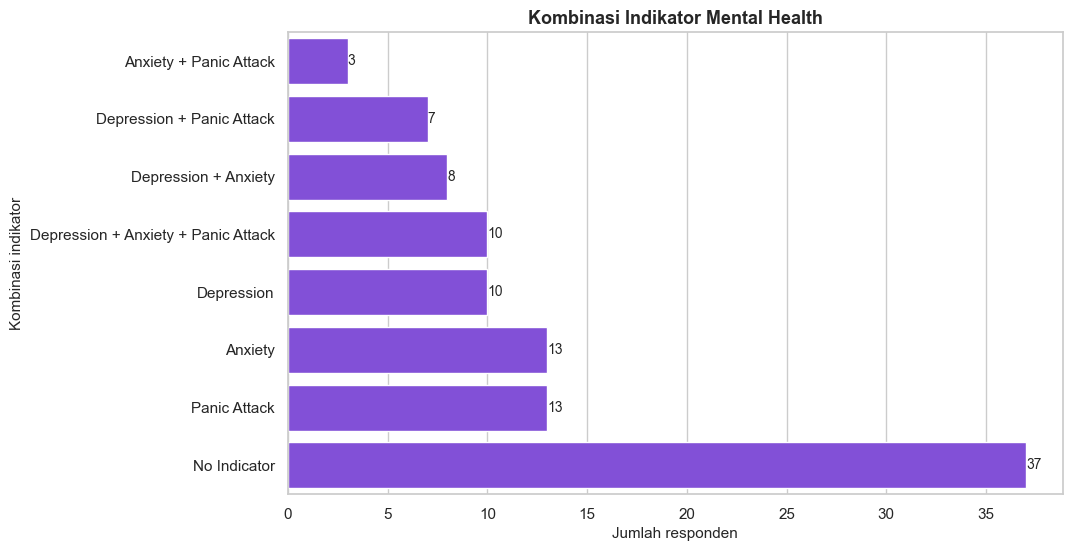

In [12]:
def combination_label(row):
    active = []
    if row['depression'] == 1:
        active.append('Depression')
    if row['anxiety'] == 1:
        active.append('Anxiety')
    if row['panic_attack'] == 1:
        active.append('Panic Attack')
    return 'No Indicator' if len(active) == 0 else ' + '.join(active)

df_clean['indicator_combination'] = df_clean.apply(combination_label, axis=1)

combination_summary = (
    df_clean['indicator_combination']
    .value_counts()
    .rename_axis('combination')
    .reset_index(name='count')
)
combination_summary['percentage'] = (combination_summary['count'] / len(df_clean) * 100).round(2)

display(combination_summary)

plt.figure(figsize=(10, 6))
plot_df = combination_summary.sort_values('count', ascending=True)
ax = sns.barplot(data=plot_df, y='combination', x='count', color='#7C3AED')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Kombinasi Indikator Mental Health')
plt.xlabel('Jumlah responden')
plt.ylabel('Kombinasi indikator')
plt.show()

,depression,anxiety,panic_attack,seek_specialist,issue_count
depression,1.00,0.27,0.25,0.35,0.74
anxiety,0.27,1.00,0.08,0.09,0.66
panic_attack,0.25,0.08,1.00,0.18,0.65
seek_specialist,0.35,0.09,0.18,1.00,0.30
issue_count,0.74,0.66,0.65,0.30,1.00


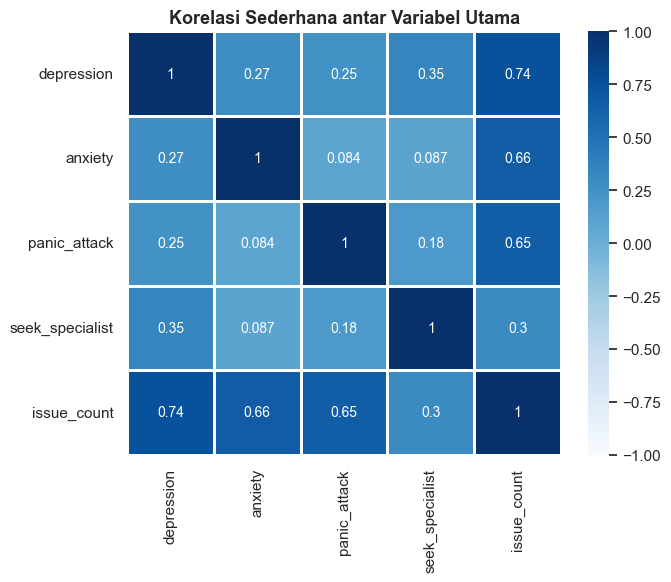

In [13]:
# Korelasi sederhana antar indikator dan pencarian bantuan.
corr_cols = ['depression', 'anxiety', 'panic_attack', 'seek_specialist', 'issue_count']
corr_matrix = df_clean[corr_cols].corr()

display(corr_matrix.round(2))

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', vmin=-1, vmax=1, linewidths=1, linecolor='white')
plt.title('Korelasi Sederhana antar Variabel Utama')
plt.show()

## 10. Analisis Utama: Support Gap dan Silent Struggle

Bagian ini adalah inti notebook. Kita ingin mengetahui berapa banyak mahasiswa yang memiliki minimal satu indikator mental health, tetapi belum mencari bantuan profesional.

Dalam konteks solusi kampus, kelompok ini disebut **Silent Struggle**.

,metric,value
0,Total responden,101.00
1,Memiliki minimal 1 indikator mental health,64.00
2,Tidak memiliki indikator mental health,37.00
3,Silent Struggle: berindikasi tetapi belum menc...,58.00
4,Reached Support: berindikasi dan sudah mencari...,6.00
5,Silent Struggle Rate among at-risk (%),90.62
6,Support Reach Rate among at-risk (%),9.38


,support_status,count,percentage
0,Stable / No Reported Indicator,37,36.63
1,Silent Struggle,58,57.43
2,Reached Support,6,5.94


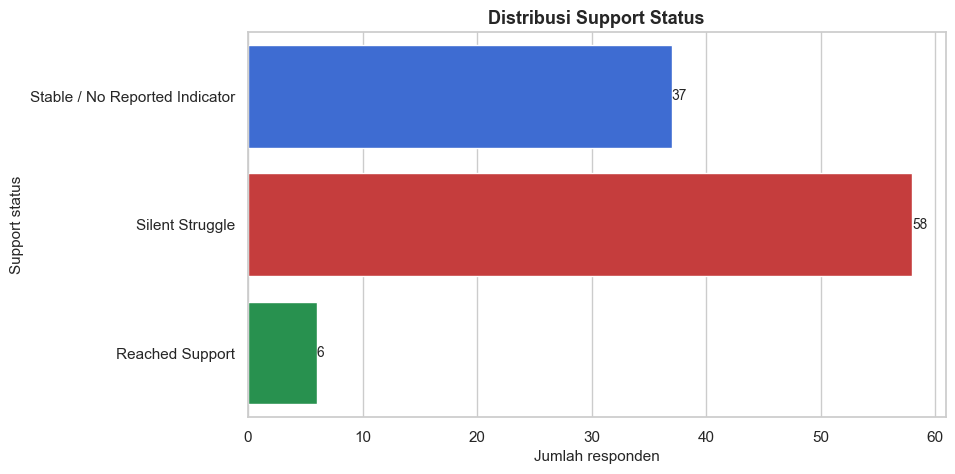

In [14]:
support_gap_summary = pd.DataFrame({
    'metric': [
        'Total responden',
        'Memiliki minimal 1 indikator mental health',
        'Tidak memiliki indikator mental health',
        'Silent Struggle: berindikasi tetapi belum mencari bantuan',
        'Reached Support: berindikasi dan sudah mencari bantuan',
        'Silent Struggle Rate among at-risk (%)',
        'Support Reach Rate among at-risk (%)'
    ],
    'value': [
        n,
        with_issue,
        without_issue,
        silent_struggle,
        reached_support,
        round(silent_struggle_rate_at_risk, 2),
        round(support_reach_rate, 2)
    ]
})

display(support_gap_summary)

status_order = ['Stable / No Reported Indicator', 'Silent Struggle', 'Reached Support']
status_palette = {
    'Stable / No Reported Indicator': '#2563EB',
    'Silent Struggle': '#DC2626',
    'Reached Support': '#16A34A'
}

support_status_summary = (
    df_clean['support_status']
    .value_counts()
    .reindex(status_order)
    .rename_axis('support_status')
    .reset_index(name='count')
)
support_status_summary['percentage'] = (support_status_summary['count'] / n * 100).round(2)

display(support_status_summary)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=support_status_summary,
    y='support_status',
    x='count',
    hue='support_status',
    hue_order=status_order,
    palette=status_palette,
    order=status_order,
    legend=False
)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Distribusi Support Status')
plt.xlabel('Jumlah responden')
plt.ylabel('Support status')
plt.show()

In [15]:
display(Markdown(f"""
### Insight utama

Dari **{with_issue}** responden yang memiliki minimal satu indikator mental health, sebanyak **{silent_struggle} responden** belum mencari bantuan profesional. Dengan kata lain, **{silent_struggle_rate_at_risk:.1f}%** mahasiswa yang sudah berindikasi masih berada dalam kelompok **Silent Struggle**.

Ini menjadi temuan paling penting karena menunjukkan bahwa layanan bantuan tidak cukup hanya tersedia. Kampus juga perlu memiliki mekanisme yang lebih proaktif, aman, dan tidak menghakimi untuk menjembatani mahasiswa dengan dukungan yang sesuai.
"""))


### Insight utama

Dari **64** responden yang memiliki minimal satu indikator mental health, sebanyak **58 responden** belum mencari bantuan profesional. Dengan kata lain, **90.6%** mahasiswa yang sudah berindikasi masih berada dalam kelompok **Silent Struggle**.

Ini menjadi temuan paling penting karena menunjukkan bahwa layanan bantuan tidak cukup hanya tersedia. Kampus juga perlu memiliki mekanisme yang lebih proaktif, aman, dan tidak menghakimi untuk menjembatani mahasiswa dengan dukungan yang sesuai.


## 11. Support Gap berdasarkan Jumlah Indikator

Analisis ini menjawab: apakah mahasiswa dengan lebih banyak indikator cenderung sudah mencari bantuan, atau justru tetap belum tersambung ke layanan profesional?

,issue_count,total,seek_support,not_seek_support,seek_support_pct,not_seek_support_pct
0,0,37,0,37,0.00,100.00
1,1,36,0,36,0.00,100.00
2,2,18,5,13,27.78,72.22
3,3,10,1,9,10.00,90.00


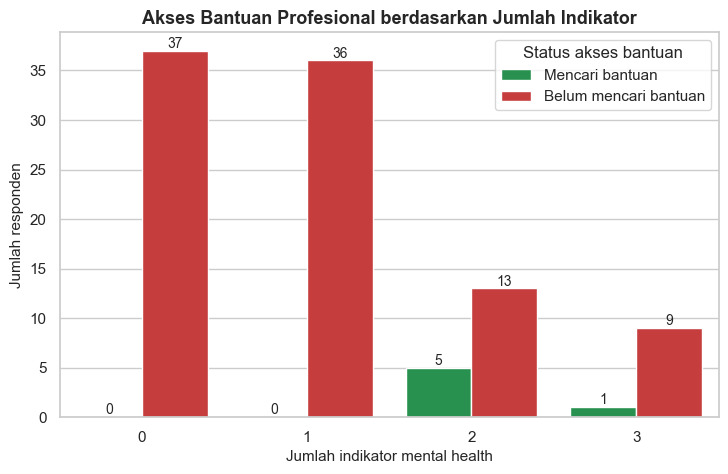

In [16]:
support_by_issue_count = (
    df_clean
    .groupby('issue_count', observed=True)
    .agg(
        total=('issue_count', 'size'),
        seek_support=('seek_specialist', 'sum')
    )
    .reset_index()
)
support_by_issue_count['not_seek_support'] = support_by_issue_count['total'] - support_by_issue_count['seek_support']
support_by_issue_count['seek_support_pct'] = (support_by_issue_count['seek_support'] / support_by_issue_count['total'] * 100).round(2)
support_by_issue_count['not_seek_support_pct'] = (support_by_issue_count['not_seek_support'] / support_by_issue_count['total'] * 100).round(2)

display(support_by_issue_count)

plot_df = support_by_issue_count.melt(
    id_vars='issue_count',
    value_vars=['seek_support', 'not_seek_support'],
    var_name='support_action',
    value_name='count'
)

label_map = {
    'seek_support': 'Mencari bantuan',
    'not_seek_support': 'Belum mencari bantuan'
}
plot_df['support_action'] = plot_df['support_action'].map(label_map)

plt.figure(figsize=(8.5, 5))
ax = sns.barplot(data=plot_df, x='issue_count', y='count', hue='support_action', palette=['#16A34A', '#DC2626'])
for container in ax.containers:
    ax.bar_label(container)
plt.title('Akses Bantuan Profesional berdasarkan Jumlah Indikator')
plt.xlabel('Jumlah indikator mental health')
plt.ylabel('Jumlah responden')
plt.legend(title='Status akses bantuan')
plt.show()

In [17]:
if (support_by_issue_count['issue_count'] >= 2).any():
    high_complexity = support_by_issue_count[support_by_issue_count['issue_count'] >= 2].copy()
    high_total = int(high_complexity['total'].sum())
    high_not_seek = int(high_complexity['not_seek_support'].sum())
    high_not_seek_pct = high_not_seek / high_total * 100 if high_total else 0
else:
    high_total = high_not_seek = high_not_seek_pct = 0

display(Markdown(f"""
### Interpretasi

Kelompok dengan **2–3 indikator** berjumlah **{high_total} responden**. Dari kelompok ini, **{high_not_seek} responden ({high_not_seek_pct:.1f}%)** belum mencari bantuan profesional.

Ini memperkuat alasan mengapa solusi perlu memiliki segmentasi prioritas. Mahasiswa dengan beberapa indikator sekaligus tidak cukup hanya dimasukkan ke kampanye awareness umum, tetapi perlu dipertimbangkan dalam jalur dukungan yang lebih terstruktur dan tetap menjaga privasi.
"""))


### Interpretasi

Kelompok dengan **2–3 indikator** berjumlah **28 responden**. Dari kelompok ini, **22 responden (78.6%)** belum mencari bantuan profesional.

Ini memperkuat alasan mengapa solusi perlu memiliki segmentasi prioritas. Mahasiswa dengan beberapa indikator sekaligus tidak cukup hanya dimasukkan ke kampanye awareness umum, tetapi perlu dipertimbangkan dalam jalur dukungan yang lebih terstruktur dan tetap menjaga privasi.


## 12. Priority Segment untuk Rancangan Solusi

Segmentasi ini dibuat agar hasil analisis bisa langsung diterjemahkan menjadi aksi. Segmentasi ini **bukan diagnosis**, tetapi pemetaan prioritas dukungan berbasis data survei.

| Segment | Kondisi | Arah tindakan |
|---|---|---|
| High Priority | 2–3 indikator dan belum mencari bantuan | Outreach anonim, self-assessment lanjutan, prioritas kampanye konseling |
| Medium Priority | 1 indikator dan belum mencari bantuan | Edukasi, mental health literacy, promosi layanan konseling |
| Reached Support | Berindikasi dan sudah mencari bantuan | Evaluasi keberlanjutan layanan |
| Stable | Tidak melaporkan indikator | Program preventif dan awareness umum |

,priority_segment,count,percentage,recommended_action
0,High Priority,22,21.78,"Outreach anonim, check-in berkala, prioritas r..."
1,Medium Priority,36,35.64,"Edukasi, self-assessment, promosi akses layanan"
2,Reached Support,6,5.94,Monitoring kepuasan dan keberlanjutan layanan
3,Stable,37,36.63,Program preventif dan awareness umum


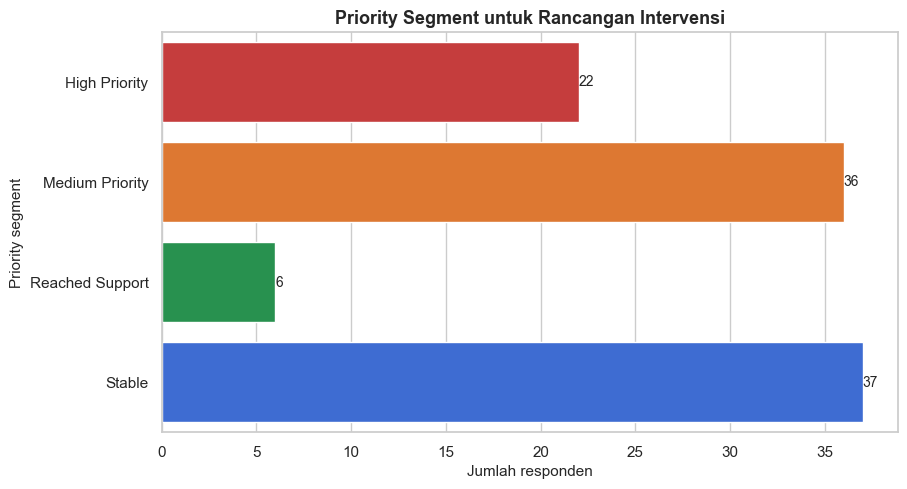

In [18]:
priority_summary = (
    df_clean['priority_segment']
    .value_counts()
    .reindex(priority_order)
    .rename_axis('priority_segment')
    .reset_index(name='count')
)
priority_summary['percentage'] = (priority_summary['count'] / n * 100).round(2)

priority_action_map = {
    'High Priority': 'Outreach anonim, check-in berkala, prioritas referral konselor',
    'Medium Priority': 'Edukasi, self-assessment, promosi akses layanan',
    'Reached Support': 'Monitoring kepuasan dan keberlanjutan layanan',
    'Stable': 'Program preventif dan awareness umum'
}
priority_summary['recommended_action'] = priority_summary['priority_segment'].astype(str).map(priority_action_map)

display(priority_summary)

priority_palette = {
    'High Priority': '#DC2626',
    'Medium Priority': '#F97316',
    'Reached Support': '#16A34A',
    'Stable': '#2563EB'
}

plt.figure(figsize=(9.5, 5.2))
ax = sns.barplot(
    data=priority_summary,
    y='priority_segment',
    x='count',
    hue='priority_segment',
    hue_order=priority_order,
    order=priority_order,
    palette=priority_palette,
    legend=False
)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Priority Segment untuk Rancangan Intervensi')
plt.xlabel('Jumlah responden')
plt.ylabel('Priority segment')
plt.show()

In [19]:
high_priority = int((df_clean['priority_segment'] == 'High Priority').sum())
medium_priority = int((df_clean['priority_segment'] == 'Medium Priority').sum())

high_priority_pct = high_priority / n * 100
medium_priority_pct = medium_priority / n * 100

display(Markdown(f"""
### Interpretasi

Segmentasi prioritas menghasilkan **{high_priority} responden ({high_priority_pct:.1f}%)** pada kelompok **High Priority** dan **{medium_priority} responden ({medium_priority_pct:.1f}%)** pada kelompok **Medium Priority**.

Dalam konteks lomba, ini bisa menjadi jembatan antara analisis dan solusi. Kampus tidak hanya mengetahui bahwa ada masalah, tetapi juga dapat menentukan kelompok mana yang perlu didukung lebih dulu melalui pendekatan yang aman dan tidak menghakimi.
"""))


### Interpretasi

Segmentasi prioritas menghasilkan **22 responden (21.8%)** pada kelompok **High Priority** dan **36 responden (35.6%)** pada kelompok **Medium Priority**.

Dalam konteks lomba, ini bisa menjadi jembatan antara analisis dan solusi. Kampus tidak hanya mengetahui bahwa ada masalah, tetapi juga dapat menentukan kelompok mana yang perlu didukung lebih dulu melalui pendekatan yang aman dan tidak menghakimi.


## 13. Analisis berdasarkan Tahun Studi

Tahun studi dapat menjadi konteks penting karena tekanan akademik berubah di setiap fase. Tahun awal berkaitan dengan adaptasi, sedangkan tahun tengah/akhir sering berkaitan dengan beban akademik, organisasi, magang, skripsi, atau persiapan karier.

,year_study,total,with_any_issue,multiple_issue,silent_struggle,reached_support,avg_issue_count,any_issue_pct,silent_struggle_pct,reached_support_pct
0,Year 1,43,25,13,22,3,0.98,58.14,51.16,6.98
1,Year 2,26,19,7,17,2,1.08,73.08,65.38,7.69
2,Year 3,24,18,7,17,1,1.17,75.00,70.83,4.17
3,Year 4,8,2,1,2,0,0.50,25.00,25.00,0.00


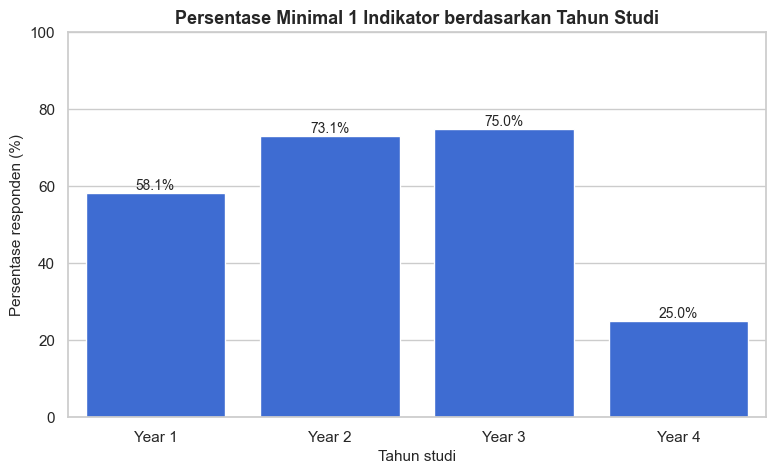

In [20]:
year_summary = (
    df_clean
    .groupby('year_study', observed=True)
    .agg(
        total=('year_study', 'size'),
        with_any_issue=('has_any_issue', 'sum'),
        multiple_issue=('multiple_issue', 'sum'),
        silent_struggle=('support_status', lambda s: (s == 'Silent Struggle').sum()),
        reached_support=('support_status', lambda s: (s == 'Reached Support').sum()),
        avg_issue_count=('issue_count', 'mean')
    )
    .reset_index()
)
year_summary['any_issue_pct'] = (year_summary['with_any_issue'] / year_summary['total'] * 100).round(2)
year_summary['silent_struggle_pct'] = (year_summary['silent_struggle'] / year_summary['total'] * 100).round(2)
year_summary['reached_support_pct'] = (year_summary['reached_support'] / year_summary['total'] * 100).round(2)
year_summary['avg_issue_count'] = year_summary['avg_issue_count'].round(2)

display(year_summary)

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=year_summary, x='year_study', y='any_issue_pct', color='#2563EB')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.title('Persentase Minimal 1 Indikator berdasarkan Tahun Studi')
plt.xlabel('Tahun studi')
plt.ylabel('Persentase responden (%)')
plt.ylim(0, 100)
plt.show()

In [21]:
year_valid = year_summary[year_summary['total'] >= 5]
top_year = year_valid.sort_values('any_issue_pct', ascending=False).iloc[0]

display(Markdown(f"""
### Interpretasi

Pada kelompok dengan jumlah data memadai, **{top_year['year_study']}** memiliki persentase minimal satu indikator tertinggi, yaitu **{top_year['any_issue_pct']:.1f}%** dari **{int(top_year['total'])} responden**.

Hasil ini dapat dijadikan sinyal awal untuk merancang program berdasarkan fase studi. Namun, karena ukuran dataset kecil, hasil ini sebaiknya tidak langsung dianggap sebagai bukti bahwa tahun tertentu pasti lebih bermasalah. Gunakan sebagai dasar eksplorasi dan validasi lanjutan.
"""))


### Interpretasi

Pada kelompok dengan jumlah data memadai, **Year 3** memiliki persentase minimal satu indikator tertinggi, yaitu **75.0%** dari **24 responden**.

Hasil ini dapat dijadikan sinyal awal untuk merancang program berdasarkan fase studi. Namun, karena ukuran dataset kecil, hasil ini sebaiknya tidak langsung dianggap sebagai bukti bahwa tahun tertentu pasti lebih bermasalah. Gunakan sebagai dasar eksplorasi dan validasi lanjutan.


## 14. Analisis berdasarkan CGPA

Analisis CGPA tidak dimaksudkan untuk menyimpulkan bahwa nilai menyebabkan masalah mental health. Tujuannya adalah melihat apakah mahasiswa dengan performa akademik berbeda tetap dapat memiliki support gap.

,cgpa,total,with_any_issue,multiple_issue,silent_struggle,reached_support,avg_issue_count,any_issue_pct,silent_struggle_pct,reached_support_pct
0,0 - 1.99,4,1,0,1,0,0.25,25.00,25.00,0.00
1,2.00 - 2.49,2,1,0,1,0,0.50,50.00,50.00,0.00
2,2.50 - 2.99,4,3,3,1,2,1.75,75.00,25.00,50.00
3,3.00 - 3.49,43,28,11,28,0,1.00,65.12,65.12,0.00
4,3.50 - 4.00,48,31,14,27,4,1.04,64.58,56.25,8.33


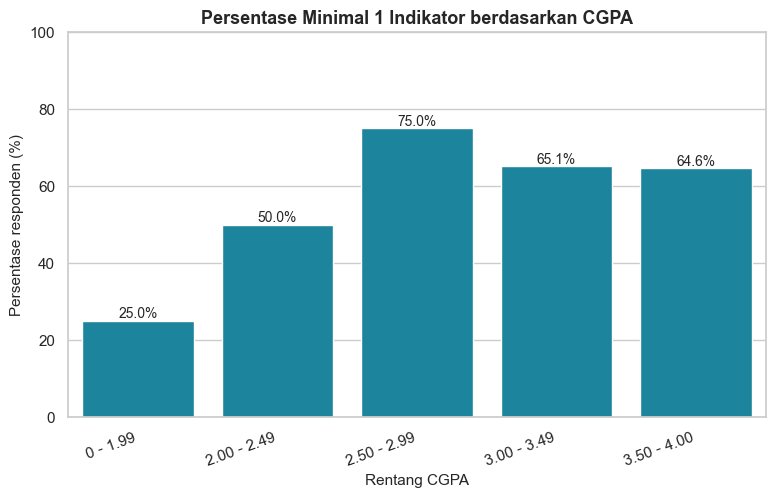

In [22]:
cgpa_summary = (
    df_clean
    .groupby('cgpa', observed=True)
    .agg(
        total=('cgpa', 'size'),
        with_any_issue=('has_any_issue', 'sum'),
        multiple_issue=('multiple_issue', 'sum'),
        silent_struggle=('support_status', lambda s: (s == 'Silent Struggle').sum()),
        reached_support=('support_status', lambda s: (s == 'Reached Support').sum()),
        avg_issue_count=('issue_count', 'mean')
    )
    .reset_index()
)
cgpa_summary['any_issue_pct'] = (cgpa_summary['with_any_issue'] / cgpa_summary['total'] * 100).round(2)
cgpa_summary['silent_struggle_pct'] = (cgpa_summary['silent_struggle'] / cgpa_summary['total'] * 100).round(2)
cgpa_summary['reached_support_pct'] = (cgpa_summary['reached_support'] / cgpa_summary['total'] * 100).round(2)
cgpa_summary['avg_issue_count'] = cgpa_summary['avg_issue_count'].round(2)

display(cgpa_summary)

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=cgpa_summary, x='cgpa', y='any_issue_pct', color='#0891B2')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.title('Persentase Minimal 1 Indikator berdasarkan CGPA')
plt.xlabel('Rentang CGPA')
plt.ylabel('Persentase responden (%)')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 100)
plt.show()

In [23]:
cgpa_valid = cgpa_summary[cgpa_summary['total'] >= 5]
top_cgpa = cgpa_valid.sort_values('any_issue_pct', ascending=False).iloc[0]

display(Markdown(f"""
### Interpretasi

Pada kategori CGPA dengan jumlah responden memadai, kelompok **{top_cgpa['cgpa']}** memiliki persentase minimal satu indikator tertinggi, yaitu **{top_cgpa['any_issue_pct']:.1f}%**.

Insight pentingnya: kondisi mental mahasiswa tidak bisa hanya diasumsikan dari performa akademik. Mahasiswa dengan CGPA baik pun tetap dapat memiliki indikator masalah mental dan belum tentu mencari bantuan.
"""))


### Interpretasi

Pada kategori CGPA dengan jumlah responden memadai, kelompok **3.00 - 3.49** memiliki persentase minimal satu indikator tertinggi, yaitu **65.1%**.

Insight pentingnya: kondisi mental mahasiswa tidak bisa hanya diasumsikan dari performa akademik. Mahasiswa dengan CGPA baik pun tetap dapat memiliki indikator masalah mental dan belum tentu mencari bantuan.


## 15. Analisis berdasarkan Gender

Distribusi gender pada dataset tidak seimbang, sehingga hasil bagian ini harus dibaca hati-hati. Tujuannya bukan membuat generalisasi besar, tetapi melihat gambaran awal pada data yang tersedia.

,gender,total,depression_rate,anxiety_rate,panic_attack_rate,any_issue_rate,multiple_issue_rate,silent_struggle_rate,reached_support_rate
0,Female,75,38.67,32.00,33.33,64.00,28.00,57.33,6.67
1,Male,26,23.08,38.46,30.77,61.54,26.92,57.69,3.85


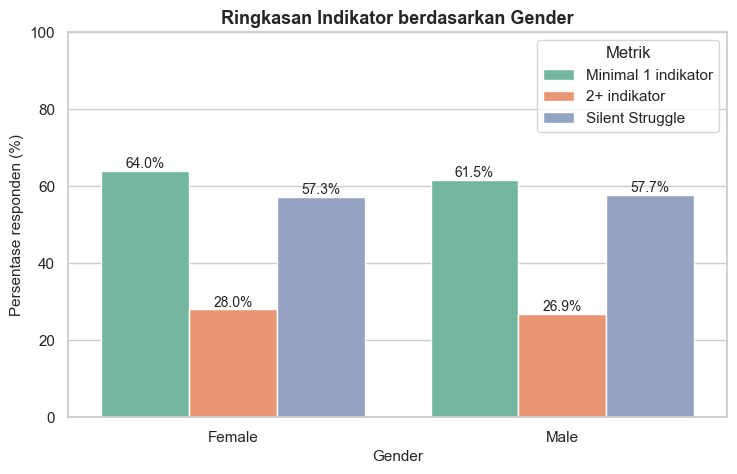

In [24]:
gender_summary = (
    df_clean
    .groupby('gender', observed=True)
    .agg(
        total=('gender', 'size'),
        depression_rate=('depression', 'mean'),
        anxiety_rate=('anxiety', 'mean'),
        panic_attack_rate=('panic_attack', 'mean'),
        any_issue_rate=('has_any_issue', 'mean'),
        multiple_issue_rate=('multiple_issue', 'mean'),
        silent_struggle_rate=('support_status', lambda s: (s == 'Silent Struggle').mean()),
        reached_support_rate=('support_status', lambda s: (s == 'Reached Support').mean())
    )
    .reset_index()
)

rate_cols = [c for c in gender_summary.columns if c.endswith('_rate')]
gender_summary[rate_cols] = (gender_summary[rate_cols] * 100).round(2)

display(gender_summary)

plt.figure(figsize=(8.5, 5))
plot_df = gender_summary.melt(
    id_vars=['gender', 'total'],
    value_vars=['any_issue_rate', 'multiple_issue_rate', 'silent_struggle_rate'],
    var_name='metric',
    value_name='percentage'
)
metric_label = {
    'any_issue_rate': 'Minimal 1 indikator',
    'multiple_issue_rate': '2+ indikator',
    'silent_struggle_rate': 'Silent Struggle'
}
plot_df['metric'] = plot_df['metric'].map(metric_label)
ax = sns.barplot(data=plot_df, x='gender', y='percentage', hue='metric', palette='Set2')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.title('Ringkasan Indikator berdasarkan Gender')
plt.xlabel('Gender')
plt.ylabel('Persentase responden (%)')
plt.ylim(0, 100)
plt.legend(title='Metrik')
plt.show()

## 16. Analisis berdasarkan Umur

Karena rentang umur pada dataset cukup sempit, analisis umur sebaiknya dipakai sebagai eksplorasi awal saja, bukan dasar generalisasi.

,age_group,total,with_any_issue,multiple_issue,silent_struggle,avg_issue_count,any_issue_pct,silent_struggle_pct
0,<=18,32,22,10,20,1.06,68.75,62.50
1,19-20,27,17,9,16,1.11,62.96,59.26
2,21-22,5,3,0,3,0.60,60.00,60.00
3,23+,36,22,9,19,0.97,61.11,52.78


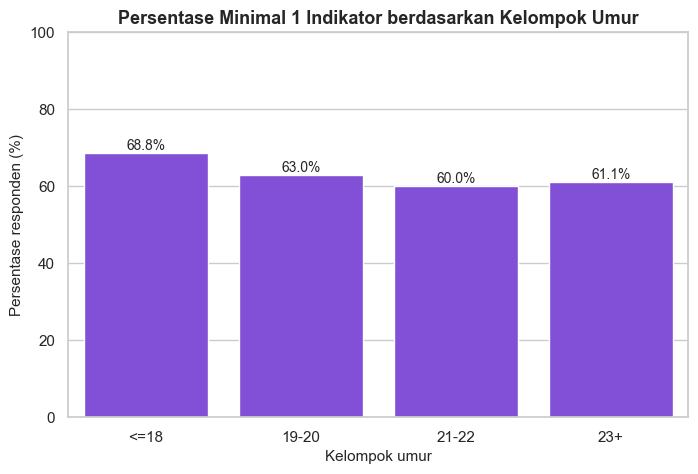

In [25]:
age_summary = (
    df_clean
    .groupby('age_group', observed=True)
    .agg(
        total=('age_group', 'size'),
        with_any_issue=('has_any_issue', 'sum'),
        multiple_issue=('multiple_issue', 'sum'),
        silent_struggle=('support_status', lambda s: (s == 'Silent Struggle').sum()),
        avg_issue_count=('issue_count', 'mean')
    )
    .reset_index()
)
age_summary['any_issue_pct'] = (age_summary['with_any_issue'] / age_summary['total'] * 100).round(2)
age_summary['silent_struggle_pct'] = (age_summary['silent_struggle'] / age_summary['total'] * 100).round(2)
age_summary['avg_issue_count'] = age_summary['avg_issue_count'].round(2)

display(age_summary)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=age_summary, x='age_group', y='any_issue_pct', color='#7C3AED')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.title('Persentase Minimal 1 Indikator berdasarkan Kelompok Umur')
plt.xlabel('Kelompok umur')
plt.ylabel('Persentase responden (%)')
plt.ylim(0, 100)
plt.show()

## 17. Analisis berdasarkan Course/Jurusan

Analisis course perlu paling hati-hati karena banyak jurusan memiliki jumlah responden kecil. Agar tidak misleading, visual utama difokuskan pada course dengan minimal jumlah responden tertentu.

> **Catatan:** persentase 100% pada kelompok kecil belum tentu berarti jurusan tersebut benar-benar paling berisiko. Bisa saja terjadi karena jumlah respondennya hanya sedikit.

,course_clean,total
0,Engineering,18
1,Computer Science,18
2,Information Technology,11
3,Koe,6
4,Islamic Education,5
5,Biomedical Science,4
6,Law,3
7,Benl,3
8,Psychology,3
9,Engine,2


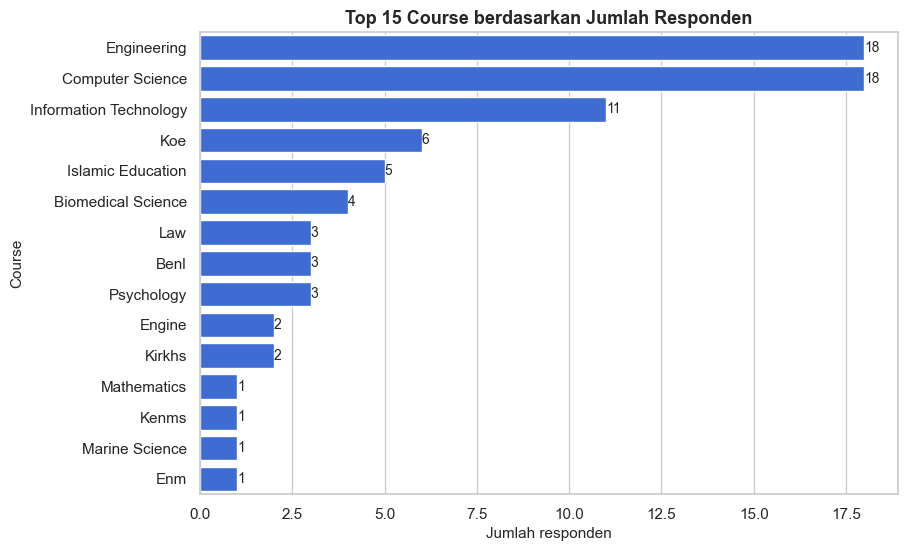

In [26]:
course_counts = (
    df_clean['course_clean']
    .value_counts()
    .rename_axis('course_clean')
    .reset_index(name='total')
)

display(course_counts.head(15))

plt.figure(figsize=(9, 6))
ax = sns.barplot(data=course_counts.head(15), y='course_clean', x='total', color='#2563EB')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Top 15 Course berdasarkan Jumlah Responden')
plt.xlabel('Jumlah responden')
plt.ylabel('Course')
plt.show()

,course_clean,total,with_any_issue,silent_struggle,high_priority,avg_issue_count,any_issue_pct,silent_struggle_pct,high_priority_pct
20,Information Technology,11,10,9,3,1.64,90.91,81.82,27.27
25,Koe,6,5,5,2,1.33,83.33,83.33,33.33
14,Engineering,18,12,11,4,0.94,66.67,61.11,22.22
8,Computer Science,18,11,9,2,0.89,61.11,50.00,11.11
22,Islamic Education,5,2,2,1,0.60,40.00,40.00,20.00


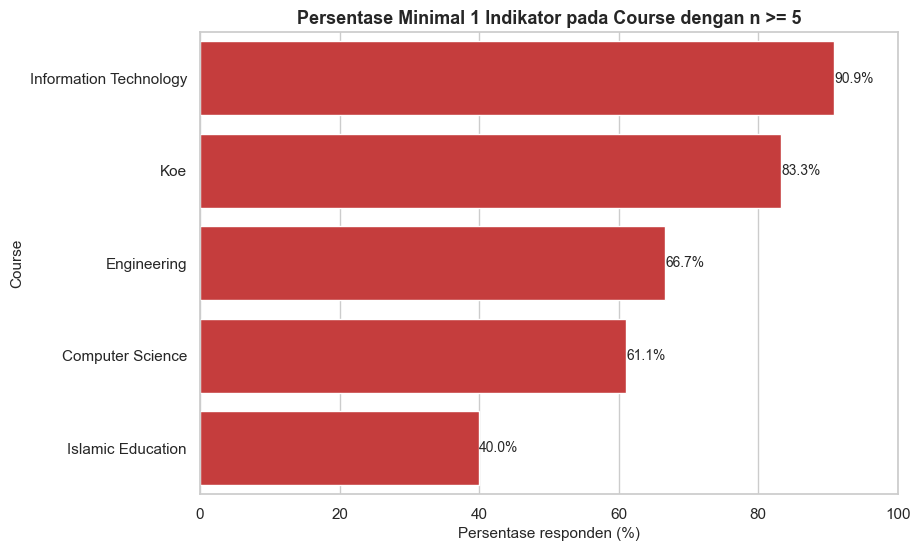

In [27]:
min_n = 5
course_issue_summary = (
    df_clean
    .groupby('course_clean', observed=True)
    .agg(
        total=('course_clean', 'size'),
        with_any_issue=('has_any_issue', 'sum'),
        silent_struggle=('support_status', lambda s: (s == 'Silent Struggle').sum()),
        high_priority=('priority_segment', lambda s: (s == 'High Priority').sum()),
        avg_issue_count=('issue_count', 'mean')
    )
    .reset_index()
)
course_issue_summary['any_issue_pct'] = (course_issue_summary['with_any_issue'] / course_issue_summary['total'] * 100).round(2)
course_issue_summary['silent_struggle_pct'] = (course_issue_summary['silent_struggle'] / course_issue_summary['total'] * 100).round(2)
course_issue_summary['high_priority_pct'] = (course_issue_summary['high_priority'] / course_issue_summary['total'] * 100).round(2)
course_issue_summary['avg_issue_count'] = course_issue_summary['avg_issue_count'].round(2)

course_issue_filtered = course_issue_summary[course_issue_summary['total'] >= min_n].sort_values(
    ['any_issue_pct', 'total'], ascending=[False, False]
)

display(course_issue_filtered)

plt.figure(figsize=(9, 6))
ax = sns.barplot(data=course_issue_filtered, y='course_clean', x='any_issue_pct', color='#DC2626')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.title(f'Persentase Minimal 1 Indikator pada Course dengan n >= {min_n}')
plt.xlabel('Persentase responden (%)')
plt.ylabel('Course')
plt.xlim(0, 100)
plt.show()

In [28]:
display(Markdown(f"""
### Interpretasi

Analisis course menggunakan batas minimal **n ≥ {min_n}** agar hasil tidak terlalu sensitif terhadap kelompok yang sangat kecil. Course dengan persentase tinggi dapat dipakai sebagai sinyal awal untuk eksplorasi lanjutan, tetapi belum cukup kuat untuk menyimpulkan bahwa jurusan tertentu pasti lebih berisiko.

Untuk implementasi nyata, kampus sebaiknya memakai jumlah sampel yang lebih besar dan periode survei yang lebih panjang sebelum membuat kebijakan berbasis jurusan.
"""))


### Interpretasi

Analisis course menggunakan batas minimal **n ≥ 5** agar hasil tidak terlalu sensitif terhadap kelompok yang sangat kecil. Course dengan persentase tinggi dapat dipakai sebagai sinyal awal untuk eksplorasi lanjutan, tetapi belum cukup kuat untuk menyimpulkan bahwa jurusan tertentu pasti lebih berisiko.

Untuk implementasi nyata, kampus sebaiknya memakai jumlah sampel yang lebih besar dan periode survei yang lebih panjang sebelum membuat kebijakan berbasis jurusan.


## 18. Analisis Hubungan Sederhana antar Variabel Kategorikal

Bagian ini menggunakan Chi-square dan Cramer's V sebagai ukuran asosiasi sederhana. Tujuannya hanya untuk eksplorasi, bukan pembuktian sebab-akibat.

In [29]:
try:
    from scipy.stats import chi2_contingency

    def cramers_v(confusion_matrix):
        chi2 = chi2_contingency(confusion_matrix)[0]
        n_obs = confusion_matrix.sum().sum()
        r, k = confusion_matrix.shape
        return np.sqrt((chi2 / n_obs) / max(min(k - 1, r - 1), 1))

    association_targets = ['gender', 'year_study', 'cgpa', 'age_group']
    assoc_rows = []
    for var in association_targets:
        table = pd.crosstab(df_clean[var], df_clean['has_any_issue'])
        if table.shape[0] > 1 and table.shape[1] > 1:
            chi2, p, dof, expected = chi2_contingency(table)
            assoc_rows.append({
                'variable': var,
                'chi2': round(chi2, 4),
                'p_value': round(p, 4),
                'cramers_v': round(cramers_v(table), 4),
                'interpretation': 'exploratory only; not causal'
            })

    association_summary = pd.DataFrame(assoc_rows).sort_values('cramers_v', ascending=False)
    display(association_summary)
except Exception as e:
    print('SciPy tidak tersedia atau terjadi error:', e)

,variable,chi2,p_value,cramers_v,interpretation
1,year_study,8.03,0.05,0.28,exploratory only; not causal
2,cgpa,3.01,0.56,0.17,exploratory only; not causal
3,age_group,0.49,0.92,0.07,exploratory only; not causal
0,gender,0.00,1.00,0.00,exploratory only; not causal


## 19. Key Insights untuk Laporan

Bagian ini merangkum insight utama dalam format yang bisa langsung dipindahkan ke worksheet atau laporan lomba.

In [30]:
# Ambil beberapa angka utama untuk narasi insight.
year_valid = year_summary[year_summary['total'] >= 5]
top_year = year_valid.sort_values('any_issue_pct', ascending=False).iloc[0]

cgpa_valid = cgpa_summary[cgpa_summary['total'] >= 5]
top_cgpa = cgpa_valid.sort_values('any_issue_pct', ascending=False).iloc[0]

insight_text = f"""
### Ringkasan Insight Utama

1. Dari total **{n} responden**, terdapat **{with_issue} responden ({at_risk_rate:.1f}%)** yang memiliki minimal satu indikator mental health, yaitu depression, anxiety, atau panic attack.

2. Dari kelompok yang memiliki indikator tersebut, sebanyak **{silent_struggle} responden** belum mencari bantuan profesional. Artinya, **{silent_struggle_rate_at_risk:.1f}%** responden berindikasi masih berada dalam kondisi **Silent Struggle**.

3. Sebanyak **{multiple_issue} responden ({multiple_indicator_rate:.1f}%)** memiliki dua atau lebih indikator sekaligus, dan **{all_three} responden ({all_three_rate:.1f}%)** melaporkan depression, anxiety, dan panic attack secara bersamaan.

4. Berdasarkan tahun studi, kelompok **{top_year['year_study']}** memiliki persentase minimal satu indikator tertinggi pada kelompok dengan jumlah data memadai, yaitu **{top_year['any_issue_pct']:.1f}%** dari **{int(top_year['total'])} responden**.

5. Berdasarkan CGPA, kelompok **{top_cgpa['cgpa']}** memiliki persentase minimal satu indikator tertinggi pada kelompok dengan jumlah data memadai, yaitu **{top_cgpa['any_issue_pct']:.1f}%**.

6. Segmentasi prioritas menghasilkan **{high_priority} responden ({high_priority_pct:.1f}%)** pada kelompok High Priority dan **{medium_priority} responden ({medium_priority_pct:.1f}%)** pada kelompok Medium Priority.

7. Insight paling penting: masalah utama bukan hanya keberadaan indikator mental health, tetapi **rendahnya keterhubungan mahasiswa berisiko dengan bantuan profesional**. Karena itu, solusi yang disarankan adalah sistem monitoring dan dukungan awal yang proaktif, anonim, dan etis.
"""

display(Markdown(insight_text))


### Ringkasan Insight Utama

1. Dari total **101 responden**, terdapat **64 responden (63.4%)** yang memiliki minimal satu indikator mental health, yaitu depression, anxiety, atau panic attack.

2. Dari kelompok yang memiliki indikator tersebut, sebanyak **58 responden** belum mencari bantuan profesional. Artinya, **90.6%** responden berindikasi masih berada dalam kondisi **Silent Struggle**.

3. Sebanyak **28 responden (27.7%)** memiliki dua atau lebih indikator sekaligus, dan **10 responden (9.9%)** melaporkan depression, anxiety, dan panic attack secara bersamaan.

4. Berdasarkan tahun studi, kelompok **Year 3** memiliki persentase minimal satu indikator tertinggi pada kelompok dengan jumlah data memadai, yaitu **75.0%** dari **24 responden**.

5. Berdasarkan CGPA, kelompok **3.00 - 3.49** memiliki persentase minimal satu indikator tertinggi pada kelompok dengan jumlah data memadai, yaitu **65.1%**.

6. Segmentasi prioritas menghasilkan **22 responden (21.8%)** pada kelompok High Priority dan **36 responden (35.6%)** pada kelompok Medium Priority.

7. Insight paling penting: masalah utama bukan hanya keberadaan indikator mental health, tetapi **rendahnya keterhubungan mahasiswa berisiko dengan bantuan profesional**. Karena itu, solusi yang disarankan adalah sistem monitoring dan dukungan awal yang proaktif, anonim, dan etis.


## 20. Rancangan Solusi: Silent Struggle Dashboard

Berdasarkan hasil analisis, solusi yang ditawarkan adalah **Silent Struggle Dashboard**, yaitu dashboard analitik untuk membantu kampus membaca support gap kesehatan mental mahasiswa secara agregat, aman, dan tidak mengarah ke diagnosis otomatis.

### Tujuan solusi

1. Membantu kampus membaca pola support gap secara cepat.
2. Mengubah data survei menjadi segmentasi prioritas yang bisa ditindaklanjuti.
3. Menjadi alat bantu unit konseling untuk perencanaan program, bukan pengganti konselor.
4. Menjaga privasi mahasiswa melalui agregasi dan anonimisasi data.

### Fitur utama

| Modul | Isi | Manfaat |
|---|---|---|
| KPI Monitoring | At-risk rate, silent struggle rate, support reach rate, multiple indicator rate | Membantu kampus memahami ukuran masalah |
| Priority Segment | High Priority, Medium Priority, Reached Support, Stable | Mengubah insight menjadi tindakan |
| Segment Explorer | Tahun studi, CGPA, gender, umur, course | Menemukan kelompok yang perlu program khusus |
| Early Support Recommendation | Rekomendasi aksi berdasarkan segmentasi | Membantu unit konseling merancang intervensi |
| Privacy & Ethics Layer | Anonimisasi, agregasi, role-based access | Mencegah penyalahgunaan data sensitif |

### Mekanisme intervensi yang disarankan

1. **High Priority**  
   Outreach anonim, self-assessment lanjutan, check-in sukarela, dan jalur referral ke konselor.

2. **Medium Priority**  
   Edukasi mental health, kampanye akses layanan, webinar coping strategy, dan reminder self-care.

3. **Reached Support**  
   Evaluasi pengalaman layanan dan monitoring keberlanjutan dukungan.

4. **Stable**  
   Program preventif, literasi mental health, dan kampanye anti-stigma.

### Prinsip penting

- Dashboard tidak boleh memberikan diagnosis.
- Data individu tidak boleh ditampilkan ke dosen atau pihak yang tidak berwenang.
- Analisis sebaiknya menggunakan data agregat.
- Mahasiswa harus tahu tujuan pengumpulan data.
- Akses detail hanya boleh diberikan kepada pihak profesional/berwenang sesuai aturan kampus.

## 21. Roadmap Implementasi Solusi

Agar solusi tidak berhenti di ide, berikut rancangan tahap implementasi yang realistis.

### Tahap 1 — Data Foundation

- Menyusun survei mental health berkala.
- Menstandarkan format data.
- Menambahkan informed consent.
- Menentukan siapa yang boleh mengakses data.

### Tahap 2 — Dashboard MVP

- Menampilkan KPI utama.
- Menampilkan priority segment.
- Menampilkan segmentasi berdasarkan tahun studi, CGPA, dan course.
- Menyediakan export laporan periodik.

### Tahap 3 — Early Support Program

- Membuat materi edukasi untuk Medium Priority.
- Membuka self-assessment lanjutan yang bersifat sukarela.
- Menyediakan form konsultasi anonim.
- Mengarahkan High Priority ke jalur konseling resmi secara aman.

### Tahap 4 — Evaluation Loop

- Mengukur perubahan silent struggle rate dari waktu ke waktu.
- Mengukur peningkatan support reach rate.
- Mengevaluasi kepuasan layanan konseling.
- Memperbaiki program berdasarkan feedback mahasiswa.

## 22. Batasan Analisis dan Etika

Bagian ini penting untuk lomba karena isu mental health termasuk sensitif.

### Batasan analisis

- Dataset hanya berisi **101 responden**, sehingga belum bisa digeneralisasi ke seluruh populasi mahasiswa.
- Data bersifat **self-reported**, sehingga dapat dipengaruhi bias jawaban.
- Analisis ini tidak membuktikan hubungan sebab-akibat.
- Beberapa kelompok, terutama course tertentu, memiliki jumlah responden kecil.
- Fitur yang tersedia masih terbatas, sehingga belum mencakup faktor seperti beban akademik, kondisi ekonomi, dukungan sosial, atau riwayat konseling.

### Etika penggunaan

- Hasil tidak boleh dipakai untuk diagnosis.
- Hasil tidak boleh dipakai untuk memberi label negatif kepada mahasiswa.
- Data harus dianonimkan dan diagregasikan.
- Intervensi harus bersifat mendukung, bukan menghukum.
- Pelibatan konselor/psikolog tetap wajib untuk implementasi nyata.

## 23. Export Data Hasil Cleaning dan Tabel Ringkasan

Cell berikut menyimpan dataset bersih dan tabel-tabel penting untuk kebutuhan dashboard, lampiran laporan, atau presentasi.

In [31]:
output_dir = Path('./outputs')
output_dir.mkdir(exist_ok=True)

df_clean.to_csv(output_dir / 'student_mental_health_cleaned.csv', index=False)
indicator_summary.to_csv(output_dir / 'indicator_summary.csv', index=False)
issue_count_summary.to_csv(output_dir / 'issue_count_summary.csv', index=False)
combination_summary.to_csv(output_dir / 'combination_summary.csv', index=False)
support_status_summary.to_csv(output_dir / 'support_status_summary.csv', index=False)
support_by_issue_count.to_csv(output_dir / 'support_by_issue_count.csv', index=False)
priority_summary.to_csv(output_dir / 'priority_summary.csv', index=False)
year_summary.to_csv(output_dir / 'year_summary.csv', index=False)
cgpa_summary.to_csv(output_dir / 'cgpa_summary.csv', index=False)
gender_summary.to_csv(output_dir / 'gender_summary.csv', index=False)
age_summary.to_csv(output_dir / 'age_summary.csv', index=False)
course_issue_summary.to_csv(output_dir / 'course_issue_summary.csv', index=False)

if 'association_summary' in globals():
    association_summary.to_csv(output_dir / 'association_summary.csv', index=False)

print('Export selesai. File tersimpan di folder outputs/:')
for file in sorted(output_dir.glob('*.csv')):
    print('-', file)

Export selesai. File tersimpan di folder outputs/:
- outputs\age_summary.csv
- outputs\association_summary.csv
- outputs\cgpa_summary.csv
- outputs\combination_summary.csv
- outputs\course_issue_summary.csv
- outputs\gender_summary.csv
- outputs\indicator_summary.csv
- outputs\issue_count_summary.csv
- outputs\priority_summary.csv
- outputs\student_mental_health_cleaned.csv
- outputs\support_by_issue_count.csv
- outputs\support_status_summary.csv
- outputs\year_summary.csv


## 24. Visualisasi Presentation-Ready

Bagian ini membuat visualisasi yang lebih cocok untuk presentasi akhir. Fokusnya adalah menunjukkan masalah utama secara cepat: **banyak mahasiswa berindikasi, tetapi belum tersambung ke bantuan profesional**.

In [32]:
viz_dir = Path('./outputs/visualizations')
viz_dir.mkdir(parents=True, exist_ok=True)

COLORS = {
    'text': '#0F172A',
    'muted': '#64748B',
    'grid': '#E2E8F0',
    'blue': '#2563EB',
    'cyan': '#0891B2',
    'green': '#16A34A',
    'orange': '#F97316',
    'red': '#DC2626',
    'purple': '#7C3AED',
    'gray': '#CBD5E1',
    'light_gray': '#F1F5F9'
}

status_palette = {
    'Stable / No Reported Indicator': COLORS['blue'],
    'Silent Struggle': COLORS['red'],
    'Reached Support': COLORS['green']
}

priority_palette = {
    'High Priority': COLORS['red'],
    'Medium Priority': COLORS['orange'],
    'Reached Support': COLORS['green'],
    'Stable': COLORS['blue']
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': COLORS['grid'],
    'axes.labelcolor': COLORS['text'],
    'xtick.color': COLORS['muted'],
    'ytick.color': COLORS['muted'],
    'text.color': COLORS['text'],
    'axes.titleweight': 'bold',
    'axes.titlesize': 15,
    'axes.labelsize': 11,
    'font.size': 10,
    'grid.color': COLORS['grid'],
    'grid.alpha': 0.55,
})

mental_cmap = LinearSegmentedColormap.from_list('mental_cmap', ['#F8FAFC', '#BFDBFE', '#60A5FA', '#F97316', '#DC2626'])


def save_viz(filename):
    plt.tight_layout()
    plt.savefig(viz_dir / filename, dpi=220, bbox_inches='tight', facecolor='white')
    plt.show()


def clean_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(COLORS['grid'])
    ax.spines['bottom'].set_color(COLORS['grid'])
    return ax

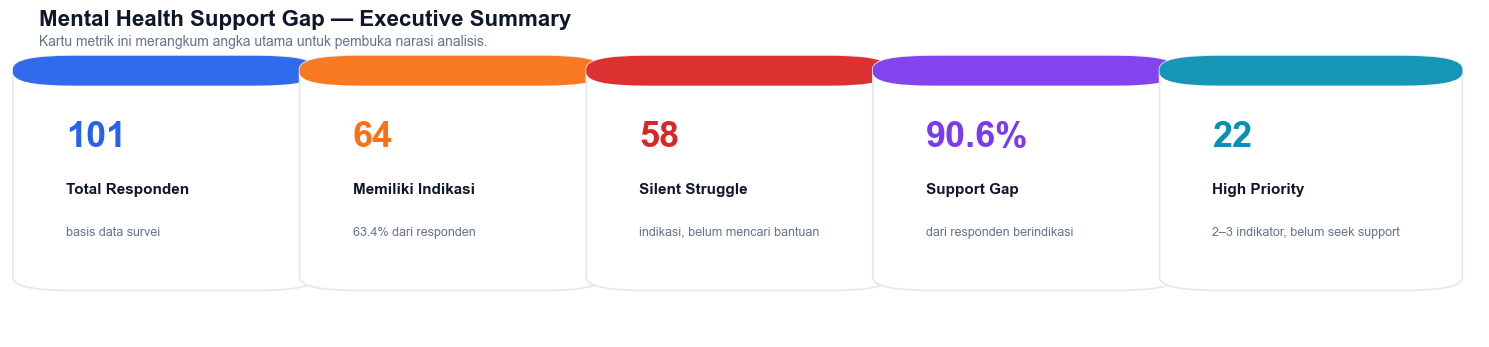

In [33]:
# 1) KPI Cards.
kpi_items = [
    ('Total Responden', f'{n}', 'basis data survei', COLORS['blue']),
    ('Memiliki Indikasi', f'{with_issue}', f'{at_risk_rate:.1f}% dari responden', COLORS['orange']),
    ('Silent Struggle', f'{silent_struggle}', 'indikasi, belum mencari bantuan', COLORS['red']),
    ('Support Gap', f'{silent_struggle_rate_at_risk:.1f}%', 'dari responden berindikasi', COLORS['purple']),
    ('High Priority', f'{high_priority}', '2–3 indikator, belum seek support', COLORS['cyan'])
]

fig, ax = plt.subplots(figsize=(15, 3.6))
ax.axis('off')

for i, (title, value, subtitle, color) in enumerate(kpi_items):
    x = 0.02 + i * 0.195
    y = 0.16
    w = 0.17
    h = 0.68
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle='round,pad=0.018,rounding_size=0.04',
        linewidth=1.2,
        edgecolor='#E2E8F0',
        facecolor='white'
    )
    ax.add_patch(box)
    ax.add_patch(FancyBboxPatch(
        (x, y + h - 0.055), w, 0.055,
        boxstyle='round,pad=0.018,rounding_size=0.04',
        linewidth=0,
        facecolor=color,
        alpha=0.95
    ))
    ax.text(x + 0.018, y + 0.45, value, fontsize=26, fontweight='bold', color=color, va='center')
    ax.text(x + 0.018, y + 0.29, title, fontsize=11, fontweight='bold', color=COLORS['text'], va='center')
    ax.text(x + 0.018, y + 0.16, subtitle, fontsize=9, color=COLORS['muted'], va='center')

ax.text(0.02, 0.95, 'Mental Health Support Gap — Executive Summary', fontsize=16, fontweight='bold')
ax.text(0.02, 0.89, 'Kartu metrik ini merangkum angka utama untuk pembuka narasi analisis.', fontsize=10, color=COLORS['muted'])

save_viz('01_kpi_cards_support_gap.png')

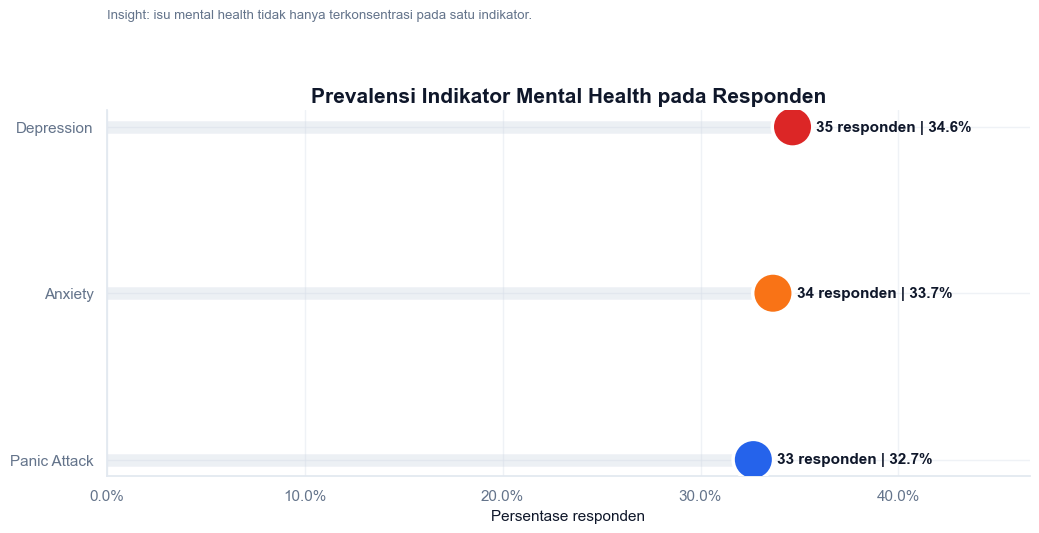

In [34]:
# 2) Lollipop Chart — prevalensi tiap indikator mental health.
indicator_plot = indicator_summary.copy()
indicator_plot['label'] = indicator_plot.apply(
    lambda r: f"{int(r['count_yes'])} responden | {r['percentage_yes']:.1f}%", axis=1
)
indicator_plot = indicator_plot.sort_values('percentage_yes')

fig, ax = plt.subplots(figsize=(10.5, 5.6))
y_pos = np.arange(len(indicator_plot))
colors = [COLORS['blue'], COLORS['orange'], COLORS['red']]

ax.hlines(
    y=y_pos,
    xmin=0,
    xmax=indicator_plot['percentage_yes'],
    color=COLORS['gray'],
    linewidth=9,
    alpha=0.35
)
ax.scatter(
    indicator_plot['percentage_yes'],
    y_pos,
    s=850,
    color=colors[:len(indicator_plot)],
    edgecolor='white',
    linewidth=2.5,
    zorder=3
)

for i, row in enumerate(indicator_plot.itertuples()):
    ax.text(row.percentage_yes + 1.2, i, row.label, va='center', fontsize=11, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(indicator_plot['indicator'])
ax.set_xlim(0, max(45, indicator_plot['percentage_yes'].max() + 12))
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Persentase responden')
ax.set_title('Prevalensi Indikator Mental Health pada Responden')
ax.text(0, len(indicator_plot) - 0.35, 'Insight: isu mental health tidak hanya terkonsentrasi pada satu indikator.', fontsize=9.5, color=COLORS['muted'])
clean_axis(ax)
save_viz('02_lollipop_prevalensi_indikator.png')

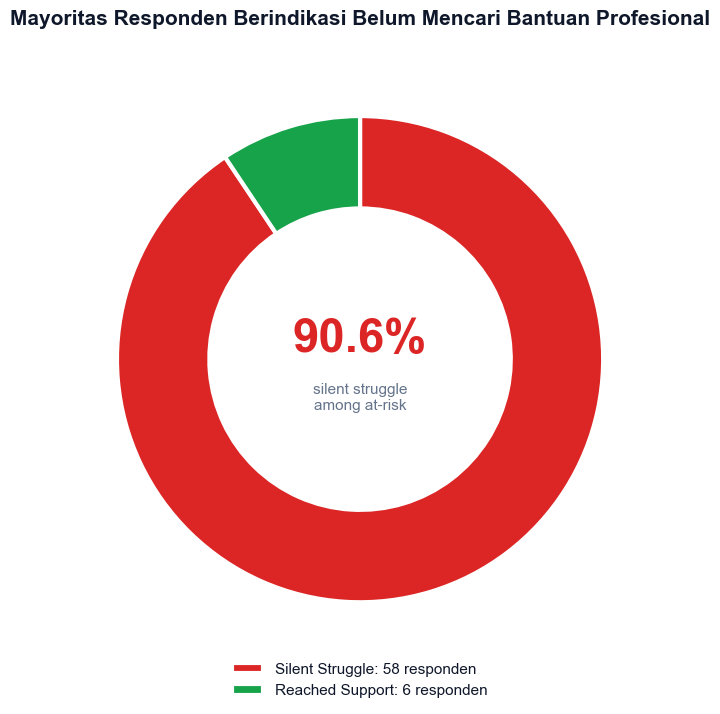

In [35]:
# 3) Donut Chart — Support Gap pada kelompok responden berindikasi.
at_risk_counts = pd.Series({
    'Silent Struggle': silent_struggle,
    'Reached Support': reached_support
})

fig, ax = plt.subplots(figsize=(7.5, 7.2))
wedges, _ = ax.pie(
    at_risk_counts.values,
    startangle=90,
    counterclock=False,
    colors=[COLORS['red'], COLORS['green']],
    wedgeprops={'width': 0.38, 'edgecolor': 'white', 'linewidth': 3}
)
ax.text(0, 0.08, f'{silent_struggle_rate_at_risk:.1f}%', ha='center', va='center', fontsize=34, fontweight='bold', color=COLORS['red'])
ax.text(0, -0.16, 'silent struggle\namong at-risk', ha='center', va='center', fontsize=11, color=COLORS['muted'])
ax.set_title('Mayoritas Responden Berindikasi Belum Mencari Bantuan Profesional', pad=22)
ax.legend(
    wedges,
    [f'{idx}: {val} responden' for idx, val in at_risk_counts.items()],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=1,
    frameon=False
)
save_viz('03_donut_support_gap.png')

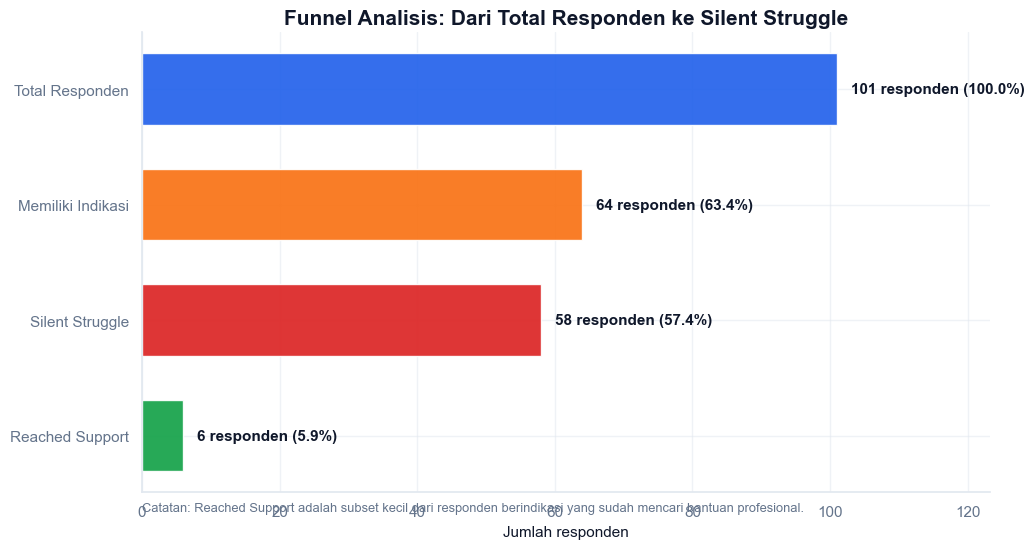

In [36]:
# 4) Funnel — dari total responden ke Silent Struggle.
funnel_df = pd.DataFrame({
    'stage': ['Total Responden', 'Memiliki Indikasi', 'Silent Struggle', 'Reached Support'],
    'count': [n, with_issue, silent_struggle, reached_support],
    'color': [COLORS['blue'], COLORS['orange'], COLORS['red'], COLORS['green']]
})

fig, ax = plt.subplots(figsize=(10.5, 5.6))
y = np.arange(len(funnel_df))
ax.barh(y, funnel_df['count'], color=funnel_df['color'], alpha=0.93, height=0.62)
for i, row in enumerate(funnel_df.itertuples()):
    pct_total = row.count / n * 100
    ax.text(row.count + 2, i, f'{row.count} responden ({pct_total:.1f}%)', va='center', fontsize=11, fontweight='bold')
ax.set_yticks(y)
ax.set_yticklabels(funnel_df['stage'])
ax.invert_yaxis()
ax.set_xlim(0, max(funnel_df['count']) * 1.22)
ax.set_xlabel('Jumlah responden')
ax.set_title('Funnel Analisis: Dari Total Responden ke Silent Struggle')
ax.text(0, 3.65, 'Catatan: Reached Support adalah subset kecil dari responden berindikasi yang sudah mencari bantuan profesional.', fontsize=9.3, color=COLORS['muted'])
clean_axis(ax)
save_viz('04_funnel_silent_struggle.png')

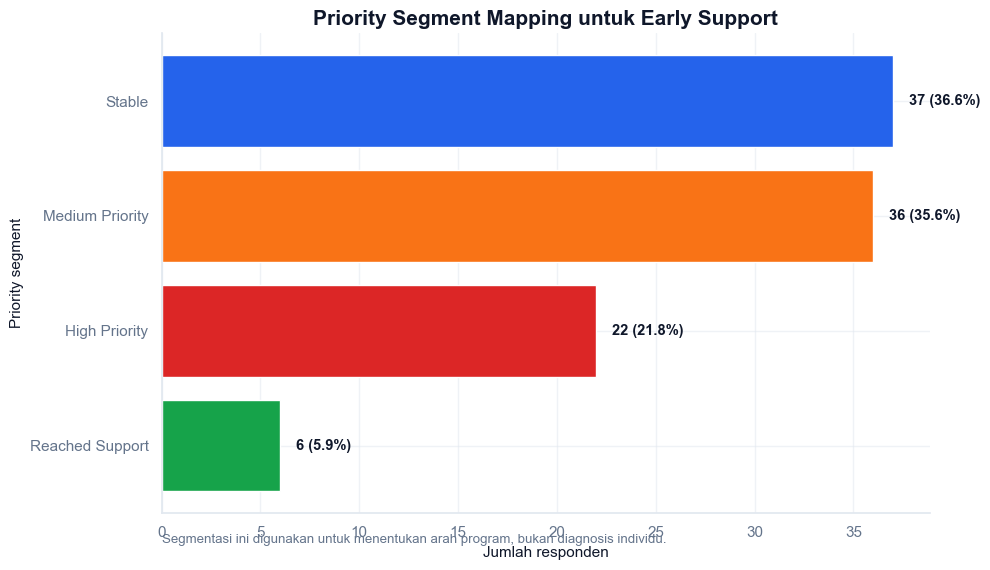

In [37]:
# 5) Priority Segment Chart.
fig, ax = plt.subplots(figsize=(10, 5.8))
priority_plot = priority_summary.copy().sort_values('count', ascending=True)
ax.barh(
    priority_plot['priority_segment'].astype(str),
    priority_plot['count'],
    color=[priority_palette[x] for x in priority_plot['priority_segment'].astype(str)]
)
for i, row in enumerate(priority_plot.itertuples()):
    ax.text(row.count + 0.8, i, f'{row.count} ({row.percentage:.1f}%)', va='center', fontsize=10.5, fontweight='bold')
ax.set_xlabel('Jumlah responden')
ax.set_ylabel('Priority segment')
ax.set_title('Priority Segment Mapping untuk Early Support')
ax.text(0, -0.85, 'Segmentasi ini digunakan untuk menentukan arah program, bukan diagnosis individu.', fontsize=9.5, color=COLORS['muted'])
clean_axis(ax)
save_viz('05_priority_segment_mapping.png')

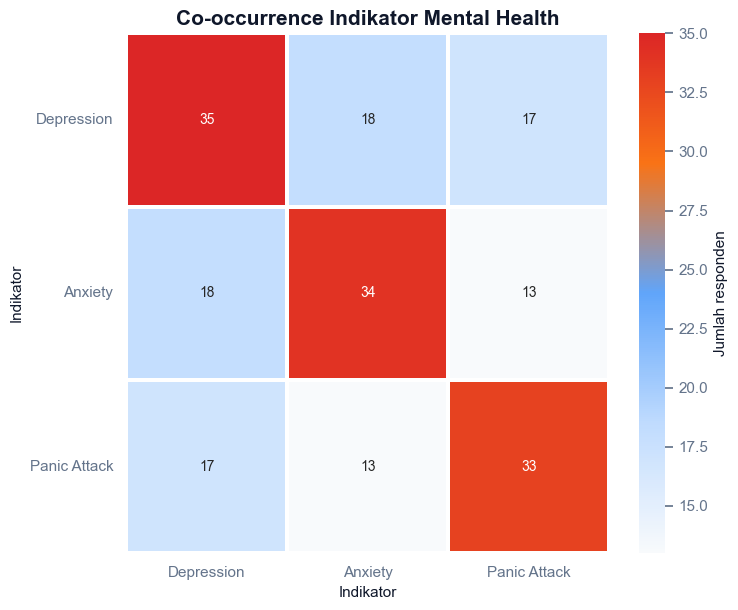

In [38]:
# 6) Co-occurrence Heatmap.
issue_names = ['Depression', 'Anxiety', 'Panic Attack']
issue_cols = ['depression', 'anxiety', 'panic_attack']
co_matrix = pd.DataFrame(index=issue_names, columns=issue_names, dtype=int)

for i, col_i in enumerate(issue_cols):
    for j, col_j in enumerate(issue_cols):
        if i == j:
            co_matrix.iloc[i, j] = int(df_clean[col_i].sum())
        else:
            co_matrix.iloc[i, j] = int(((df_clean[col_i] == 1) & (df_clean[col_j] == 1)).sum())

fig, ax = plt.subplots(figsize=(7.5, 6.2))
sns.heatmap(
    co_matrix,
    annot=True,
    fmt='.0f',
    cmap=mental_cmap,
    linewidths=1.5,
    linecolor='white',
    cbar_kws={'label': 'Jumlah responden'},
    ax=ax
)
ax.set_title('Co-occurrence Indikator Mental Health')
ax.set_xlabel('Indikator')
ax.set_ylabel('Indikator')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
save_viz('06_heatmap_cooccurrence_indikator.png')

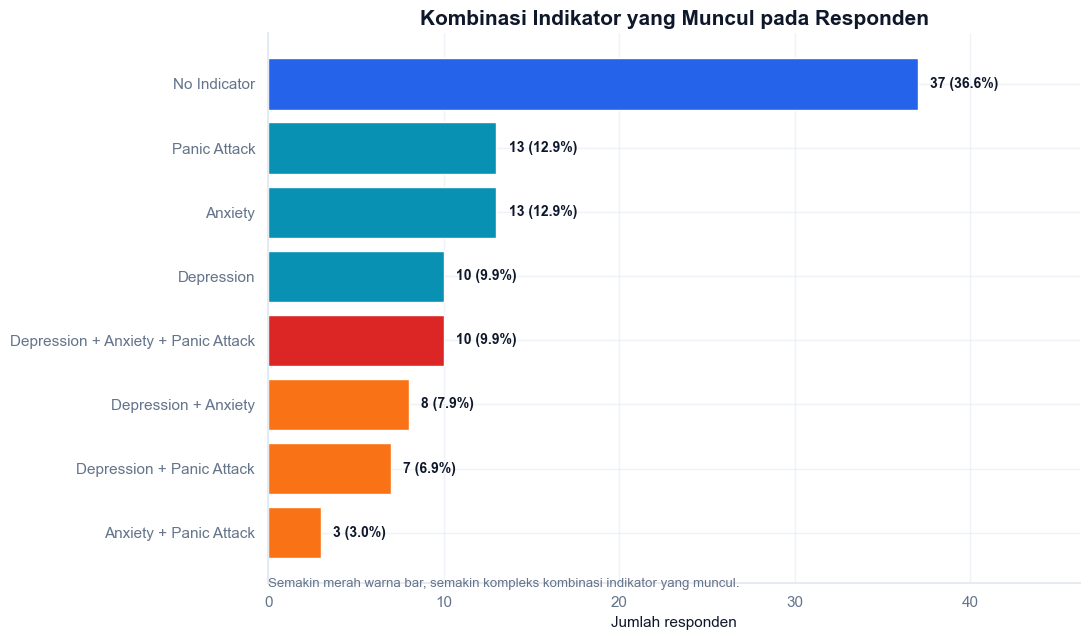

In [39]:
# 7) Kombinasi indikator.
comb_plot = combination_summary.copy()
comb_plot['issue_count_visual'] = comb_plot['combination'].apply(lambda x: 0 if x == 'No Indicator' else x.count('+') + 1)
comb_plot = comb_plot.sort_values('count', ascending=True)
combo_colors = comb_plot['issue_count_visual'].map({
    0: COLORS['blue'],
    1: COLORS['cyan'],
    2: COLORS['orange'],
    3: COLORS['red']
})

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.barh(comb_plot['combination'], comb_plot['count'], color=combo_colors)
for i, row in enumerate(comb_plot.itertuples()):
    ax.text(row.count + 0.7, i, f'{row.count} ({row.percentage:.1f}%)', va='center', fontsize=10, fontweight='bold')
ax.set_xlim(0, comb_plot['count'].max() * 1.25)
ax.set_xlabel('Jumlah responden')
ax.set_title('Kombinasi Indikator yang Muncul pada Responden')
ax.text(0, -0.85, 'Semakin merah warna bar, semakin kompleks kombinasi indikator yang muncul.', fontsize=9.5, color=COLORS['muted'])
clean_axis(ax)
save_viz('07_bar_kombinasi_indikator.png')

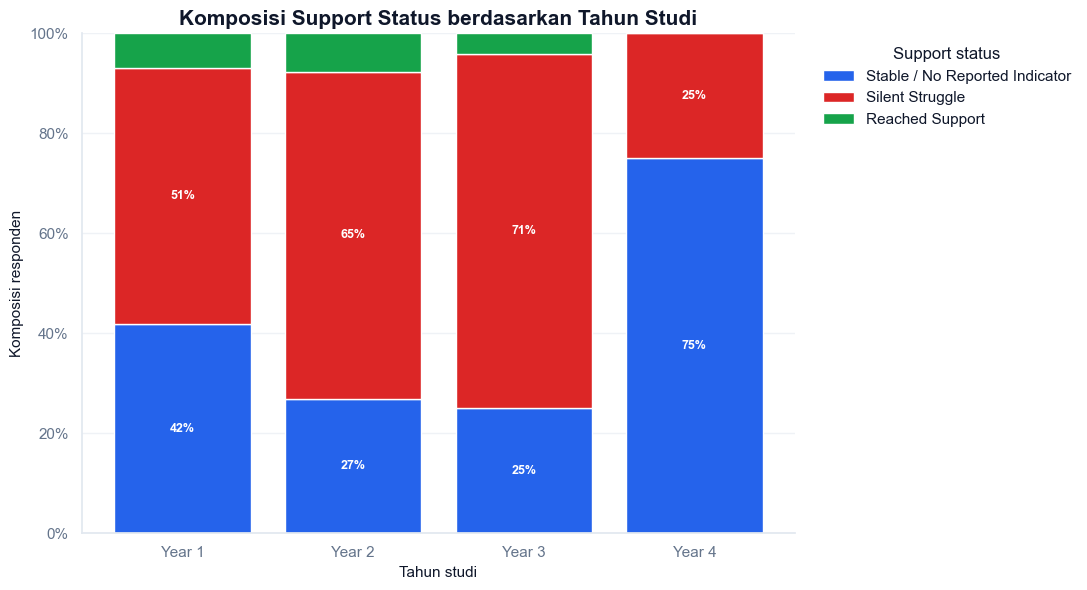

In [40]:
# 8) 100% stacked bar — support status berdasarkan tahun studi.
status_count_year = pd.crosstab(df_clean['year_study'], df_clean['support_status']).reindex(columns=status_order, fill_value=0)
status_pct_year = status_count_year.div(status_count_year.sum(axis=1), axis=0).mul(100).fillna(0)

fig, ax = plt.subplots(figsize=(11, 6))
bottom = np.zeros(len(status_pct_year))
for status in status_order:
    values = status_pct_year[status].values
    bars = ax.bar(status_pct_year.index.astype(str), values, bottom=bottom, label=status, color=status_palette[status])
    for bar, val, base in zip(bars, values, bottom):
        if val >= 9:
            ax.text(bar.get_x() + bar.get_width()/2, base + val/2, f'{val:.0f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottom += values
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Tahun studi')
ax.set_ylabel('Komposisi responden')
ax.set_title('Komposisi Support Status berdasarkan Tahun Studi')
ax.legend(title='Support status', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
clean_axis(ax)
save_viz('08_stacked_support_status_tahun_studi.png')

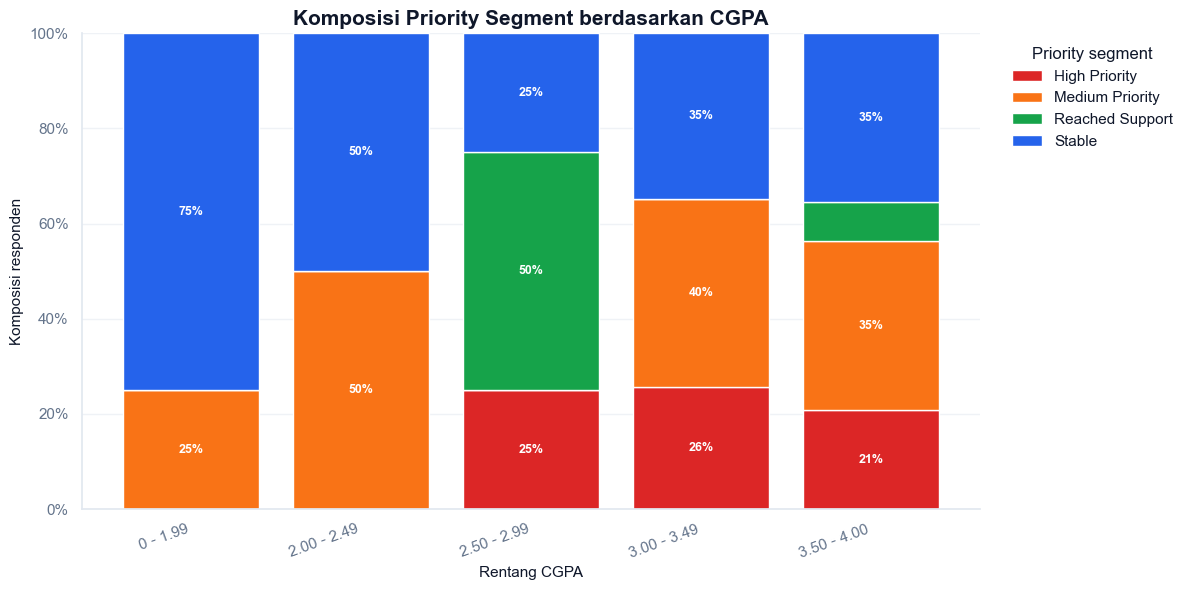

In [41]:
# 9) 100% stacked bar — priority segment berdasarkan CGPA.
priority_count_cgpa = pd.crosstab(df_clean['cgpa'], df_clean['priority_segment']).reindex(columns=priority_order, fill_value=0)
priority_pct_cgpa = priority_count_cgpa.div(priority_count_cgpa.sum(axis=1), axis=0).mul(100).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(priority_pct_cgpa))
for segment in priority_order:
    values = priority_pct_cgpa[segment].values
    bars = ax.bar(priority_pct_cgpa.index.astype(str), values, bottom=bottom, label=segment, color=priority_palette[segment])
    for bar, val, base in zip(bars, values, bottom):
        if val >= 9:
            ax.text(bar.get_x() + bar.get_width()/2, base + val/2, f'{val:.0f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottom += values
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Rentang CGPA')
ax.set_ylabel('Komposisi responden')
ax.set_title('Komposisi Priority Segment berdasarkan CGPA')
plt.xticks(rotation=20, ha='right')
ax.legend(title='Priority segment', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
clean_axis(ax)
save_viz('09_stacked_priority_segment_cgpa.png')

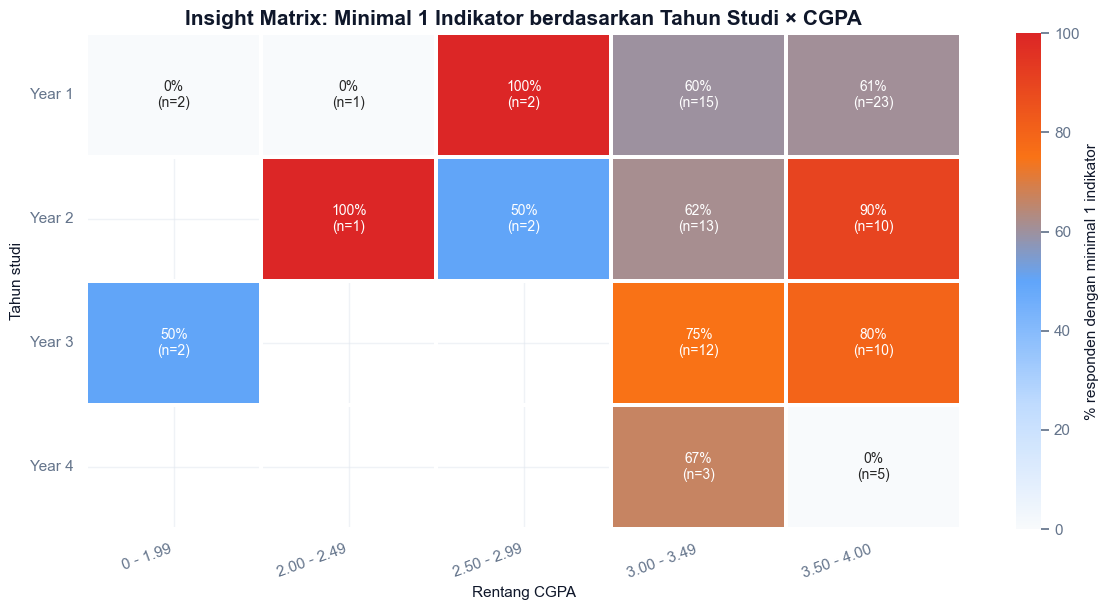

In [42]:
# 10) Insight Matrix — persentase minimal 1 indikator berdasarkan tahun studi dan CGPA.
risk_matrix = pd.pivot_table(
    df_clean,
    values='has_any_issue',
    index='year_study',
    columns='cgpa',
    aggfunc='mean',
    observed=True
).mul(100)

count_matrix = pd.pivot_table(
    df_clean,
    values='has_any_issue',
    index='year_study',
    columns='cgpa',
    aggfunc='count',
    observed=True
)

annot_matrix = risk_matrix.copy().astype(object)
for idx in risk_matrix.index:
    for col in risk_matrix.columns:
        val = risk_matrix.loc[idx, col]
        count = count_matrix.loc[idx, col]
        if pd.isna(val):
            annot_matrix.loc[idx, col] = ''
        else:
            annot_matrix.loc[idx, col] = f'{val:.0f}%\n(n={int(count)})'

fig, ax = plt.subplots(figsize=(12, 6.2))
sns.heatmap(
    risk_matrix,
    annot=annot_matrix,
    fmt='',
    cmap=mental_cmap,
    vmin=0,
    vmax=100,
    linewidths=1.5,
    linecolor='white',
    cbar_kws={'label': '% responden dengan minimal 1 indikator'},
    ax=ax
)
ax.set_title('Insight Matrix: Minimal 1 Indikator berdasarkan Tahun Studi × CGPA')
ax.set_xlabel('Rentang CGPA')
ax.set_ylabel('Tahun studi')
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
save_viz('10_heatmap_tahun_cgpa_any_issue.png')

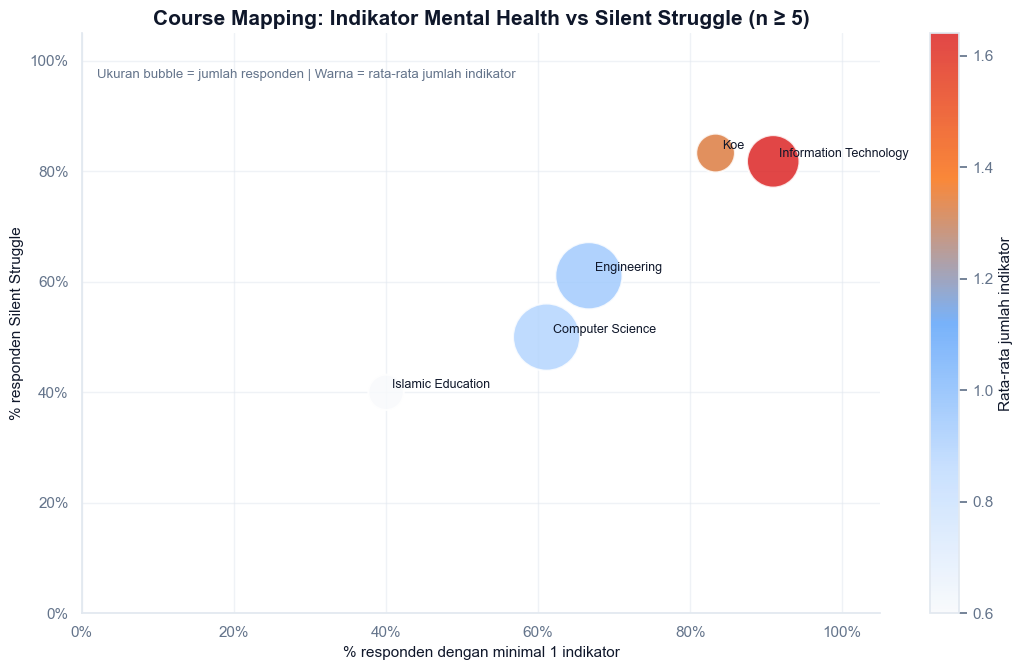

In [43]:
# 11) Course Bubble Chart — fokus course dengan jumlah responden memadai.
course_bubble = course_issue_summary[course_issue_summary['total'] >= min_n].copy()
course_bubble = course_bubble.sort_values('silent_struggle_pct', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(11, 6.8))
scatter = ax.scatter(
    course_bubble['any_issue_pct'],
    course_bubble['silent_struggle_pct'],
    s=course_bubble['total'] * 130,
    c=course_bubble['avg_issue_count'],
    cmap=mental_cmap,
    alpha=0.85,
    edgecolor='white',
    linewidth=1.5
)
for row in course_bubble.itertuples():
    ax.text(row.any_issue_pct + 0.8, row.silent_struggle_pct + 0.8, row.course_clean, fontsize=9)
ax.set_xlim(0, 105)
ax.set_ylim(0, 105)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('% responden dengan minimal 1 indikator')
ax.set_ylabel('% responden Silent Struggle')
ax.set_title(f'Course Mapping: Indikator Mental Health vs Silent Struggle (n ≥ {min_n})')
ax.text(2, 97, 'Ukuran bubble = jumlah responden | Warna = rata-rata jumlah indikator', fontsize=9.5, color=COLORS['muted'])
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Rata-rata jumlah indikator')
clean_axis(ax)
save_viz('11_bubble_course_mapping.png')

In [44]:
# Daftar file visualisasi yang berhasil dibuat.
viz_files = sorted(viz_dir.glob('*.png'))
print('Visualisasi presentation-ready tersimpan di:')
print(viz_dir)
print('\nDaftar file:')
for file in viz_files:
    print('-', file.name)

Visualisasi presentation-ready tersimpan di:
outputs\visualizations

Daftar file:
- 01_kpi_cards_support_gap.png
- 02_lollipop_prevalensi_indikator.png
- 03_donut_support_gap.png
- 04_funnel_silent_struggle.png
- 05_heatmap_cooccurrence_indikator.png
- 05_priority_segment_mapping.png
- 06_bar_kombinasi_indikator.png
- 06_heatmap_cooccurrence_indikator.png
- 07_bar_kombinasi_indikator.png
- 07_stacked_support_status_tahun_studi.png
- 08_stacked_support_status_cgpa.png
- 08_stacked_support_status_tahun_studi.png
- 09_heatmap_tahun_cgpa_any_issue.png
- 09_stacked_priority_segment_cgpa.png
- 10_bubble_course_mapping.png
- 10_heatmap_tahun_cgpa_any_issue.png
- 11_bubble_course_mapping.png


## 25. Gallery Visualisasi Exported

Bagian ini menampilkan file PNG yang sudah diekspor ke folder `outputs/visualizations/`. Saat notebook dibuka dari file ZIP, visualisasi berikut bisa langsung terlihat tanpa harus menjalankan ulang semua cell.

### KPI Cards Support Gap

![KPI Cards Support Gap](outputs/visualizations/01_kpi_cards_support_gap.png)

### Prevalensi Indikator Mental Health

![Prevalensi Indikator Mental Health](outputs/visualizations/02_lollipop_prevalensi_indikator.png)

### Donut Chart Support Gap

![Donut Chart Support Gap](outputs/visualizations/03_donut_support_gap.png)

### Funnel Silent Struggle

![Funnel Silent Struggle](outputs/visualizations/04_funnel_silent_struggle.png)

### Priority Segment Mapping

![Priority Segment Mapping](outputs\visualizations\05_priority_segment_mapping.png)

### Heatmap Co-occurrence Indikator

![Heatmap Co-occurrence Indikator](outputs/visualizations/06_heatmap_cooccurrence_indikator.png)

### Kombinasi Indikator

![Kombinasi Indikator](outputs/visualizations/07_bar_kombinasi_indikator.png)

### Support Status berdasarkan Tahun Studi

![Support Status berdasarkan Tahun Studi](outputs/visualizations/08_stacked_support_status_tahun_studi.png)

### Priority Segment berdasarkan CGPA

![Priority Segment berdasarkan CGPA](outputs/visualizations/09_stacked_priority_segment_cgpa.png)

### Insight Matrix Tahun Studi × CGPA

![Insight Matrix Tahun Studi × CGPA](outputs/visualizations/10_heatmap_tahun_cgpa_any_issue.png)

### Course Mapping Bubble Chart

![Course Mapping Bubble Chart](outputs/visualizations/11_bubble_course_mapping.png)

## 26. Final Takeaway

Berdasarkan dataset ini, isu paling kuat untuk diangkat dalam lomba adalah **Silent Struggle**, yaitu kondisi ketika mahasiswa sudah menunjukkan indikator masalah mental health tetapi belum mencari bantuan profesional.

Solusi yang paling sesuai bukan sistem diagnosis, melainkan **dashboard support gap** yang membantu kampus:

- memahami ukuran masalah,
- melihat kelompok prioritas,
- menyusun program early support,
- dan mengevaluasi apakah layanan kampus makin mudah dijangkau mahasiswa.

Dengan framing ini, analisis menjadi lebih tajam karena tidak berhenti pada pertanyaan “berapa banyak mahasiswa yang berisiko?”, tetapi lanjut ke pertanyaan yang lebih actionable: **bagaimana kampus bisa menjembatani mahasiswa berisiko dengan dukungan yang tepat secara aman dan etis?**